## Qualtrics Data

In [1]:
import pandas as pd
 # ----------- First Experiment -----------
exp_start_time = pd.to_datetime("2025-08-18 6:00:00")
exp_end_time = pd.to_datetime("2025-08-20 15:00:00")
csv_path = "results/DPU+Explanations+-+Prolific+-+BetweenSubject_August+20.csv" # first experiment


qualtrics_results = pd.read_csv(csv_path)

# Clean the data first - remove any rows where StartDate might be the header or invalid
qualtrics_results = qualtrics_results[qualtrics_results['StartDate'] != 'Start Date'].copy()  # Remove header rows if any
qualtrics_results = qualtrics_results.dropna(subset=['StartDate'])  # Remove rows with missing StartDate
print(f"df_cleaned first StartDate and ProlificID values:\n{qualtrics_results[['StartDate', 'ProlificID']].tail(3)}")

# Convert to datetime with error handling
try:
    qualtrics_results['StartDate'] = pd.to_datetime(qualtrics_results['StartDate'], errors='coerce')
    
    # Filter the data
    rellevant_qualtrics = qualtrics_results[
        (qualtrics_results['StartDate'] >= exp_start_time) & (qualtrics_results['StartDate'] <= exp_end_time) &
        (qualtrics_results['ProlificID'].astype(str).str.len() > 20) &
        (qualtrics_results['Finished'] == 'True')  # Ensure the survey was completed
        
    ]
    
    print(f"Cleaned data shape: {qualtrics_results.shape}")
    print(f"Filtered data shape: {rellevant_qualtrics.shape}")

except Exception as e:
    print(f"Error in datetime conversion: {e}")
    print("Let's examine the problematic values:")
    print(qualtrics_results['StartDate'].value_counts().head(10))

df_cleaned first StartDate and ProlificID values:
               StartDate                ProlificID
496  2025-08-20 03:25:28  5d1290103b20b0000102e8e3
497  2025-08-20 04:06:30  66a41543adadffb17baf40b8
498  2025-08-20 03:18:14  5e63f5da8a25da181c011cad
Cleaned data shape: (498, 104)
Filtered data shape: (284, 104)


C:\Users\matan\AppData\Local\Temp\ipykernel_19036\4094661481.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  qualtrics_results['StartDate'] = pd.to_datetime(qualtrics_results['StartDate'], errors='coerce')


In [2]:
#find a specific participant
rellevant_qualtrics[rellevant_qualtrics['prolific_id'] == '673153d88d13bed22065fd88']

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,AI_4,AI_5,comments,Q261,Random_ID,AWSURL,group,ProlificID,agent_level,bonus_group
479,2025-08-20 02:54:24,2025-08-20 03:38:58,IP Address,82.132.222.197,100,2673,True,2025-08-20 03:38:58,R_2c1xtW8WyrHV1SA,NaN,...,4. Neither agree nor disagree,5,"Very interesting study, thank you. In this cas...",NaN,2626664304,NaN,1,673153d88d13bed22065fd88,APPL3,2323


## DPU SQL Data

In [3]:

# import sys
# import os
# sys.path.append(os.getcwd())
from mysql_data_explorer import get_all_tables_from_mysql, alter_database_tables
import pandas as pd

all_tabels = get_all_tables_from_mysql()
print(all_tabels.keys())

✅ Connected to Azure MySQL database: mysql_dpu
📊 Found 5 tables: ['actions', 'feedback_actions', 'tutorial_actions', 'user_choices', 'users']


c:\Users\matan\master_thesis\minigrid_custom\mysql_data_explorer.py:83: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)
c:\Users\matan\master_thesis\minigrid_custom\mysql_data_explorer.py:83: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


   ✅ Loaded 'actions': 0 rows, 11 columns
   ✅ Loaded 'feedback_actions': 4460 rows, 12 columns
   ✅ Loaded 'tutorial_actions': 15652 rows, 8 columns
   ✅ Loaded 'user_choices': 1407 rows, 16 columns
   ✅ Loaded 'users': 367 rows, 5 columns
🔌 Database connection closed
dict_keys(['actions', 'feedback_actions', 'tutorial_actions', 'user_choices', 'users'])


In [4]:
# Delete the existing new_agent_score column and create new_agent_score_list column
# alter_database_tables("ALTER TABLE users CHANGE COLUMN simillarity_level similarity_level INT;")
# alter_database_tables("ALTER TABLE user_choices ADD COLUMN old_agent_score_list TEXT;")


In [5]:
users_df = all_tabels['users']
users_df.tail(10)

,id,user_id,timestamp,similarity_level,final_score
357,358,91,2025-09-10 08:42:14,NaN,12.6
358,359,Pilot_test12419238749832147523084523,2025-09-10 12:36:36,NaN,12.9
359,360,637e3bedd8c3601a81a65889,2025-09-10 13:00:03,NaN,12.8
360,361,55e876f25e4d360012cc283d,2025-09-10 13:02:27,NaN,12.8
361,362,5bce39ceb8bc680001c67555,2025-09-10 13:04:50,NaN,13.3
362,363,56ebadebcdfa81000d9e2b67,2025-09-10 13:06:26,NaN,14.5
363,364,5c81582c4c1a61000155584f,2025-09-10 13:17:14,NaN,13.4
364,365,5aff33bae55f90000139f664,2025-09-10 13:23:55,NaN,14.4
365,366,5ea9a6a68db51d0dfd2edfe2,2025-09-10 13:33:16,NaN,14.5
366,367,67606cca6591f7023be55e8e,2025-09-10 13:51:53,NaN,13.8


In [6]:
feedback_actions = all_tabels['feedback_actions']
feedback_actions['feedback_unique_env'] = feedback_actions['feedback_unique_env'].fillna(0).astype(int)
feedback_actions['timestamp'] = pd.to_datetime(feedback_actions['timestamp'], errors='coerce')

print(feedback_actions.columns)
feedback_actions.tail(15)

Index(['id', 'user_id', 'env_state', 'agent_action', 'feedback_action',
       'feedback_explanation', 'action_index', 'timestamp', 'episode_index',
       'agent_path', 'similarity_level', 'feedback_unique_env'],
      dtype='object')


,id,user_id,env_state,agent_action,feedback_action,feedback_explanation,action_index,timestamp,episode_index,agent_path,similarity_level,feedback_unique_env
4445,4446,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [2, 5, 0], [1, 0, 0], ...",2,2,,5,2025-09-10 14:20:04,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4446,4447,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",1,2,,7,2025-09-10 14:20:04,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4447,4448,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3,2,,8,2025-09-10 14:20:05,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4448,4449,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [2, 5, 0], ...",2,0,,6,2025-09-10 14:20:05,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4449,4450,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",1,2,,9,2025-09-10 14:20:05,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4450,4451,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",2,0,,10,2025-09-10 14:20:05,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4451,4452,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",1,3,,14,2025-09-10 14:20:06,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4452,4453,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3,1,,16,2025-09-10 14:20:06,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4453,4454,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",2,1,,19,2025-09-10 14:20:06,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12
4454,4455,631610af8e747093cd90e00d,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",1,2,,20,2025-09-10 14:20:07,5,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",1.0,12


In [7]:
import numpy as np

user_choices_results = all_tabels['user_choices']
user_choices_results.columns
# Fill NaN with empty string, then split each string by ',' into a list
user_choices_results['unique_envs'] = user_choices_results['unique_envs'].fillna("").apply(lambda x: x.split(',') if x != "" else [])
# Only invert 'choice_to_update' for rows before 2025-07-29
cutoff_date = pd.to_datetime('2025-07-29')
# Convert 'timestamp' to datetime if it's not already
if user_choices_results['timestamp'].dtype == object:
    user_choices_results['timestamp'] = pd.to_datetime(user_choices_results['timestamp'], errors='coerce')

mask = user_choices_results['timestamp'] < cutoff_date
user_choices_results.loc[mask, 'choice_to_update'] = 1 - user_choices_results.loc[mask, 'choice_to_update']
user_choices_results.tail(10)

,id,user_id,old_agent_path,new_agent_path,timestamp,demonstration_time,episode_index,choice_to_update,choice_explanation,similarity_level,feedback_count,feedback_score,unique_envs,examples_shown,new_agent_score_list,old_agent_score_list
1397,1398,67606cca6591f7023be55e8e,"models/-1,4,-1,0.2,0.1Steps60Grid8_20250618/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-09-10 13:49:15,2025-09-10 13:49:07,4,0,,3,1.0,1.0,[18],1.0,6.1,2.7
1398,1399,67606cca6591f7023be55e8e,"models/-1,4,-1,0.2,0.1Steps60Grid8_20250618/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-09-10 13:50:01,2025-09-10 13:49:49,5,0,,3,1.0,1.0,[9],1.0,3.1,-0.4
1399,1400,631610af8e747093cd90e00d,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...","models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",2025-09-10 14:02:02,2025-09-10 14:01:06,1,1,,1,3.0,3.0,[3],1.0,8.1,1.4
1400,1401,631610af8e747093cd90e00d,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-09-10 14:03:43,2025-09-10 14:03:10,2,1,,1,2.0,1.0,[4],1.0,6.3,4.7
1401,1402,631610af8e747093cd90e00d,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",2025-09-10 14:06:28,2025-09-10 14:06:14,3,1,,1,7.0,3.0,[9],1.0,6.5,3.1
1402,1403,631610af8e747093cd90e00d,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-09-10 14:07:45,2025-09-10 14:07:22,4,1,,1,4.0,0.0,[5],1.0,12.1,9.8
1403,1404,30,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...","models/-1,4,-1,0.2,0.1Steps60Grid8_20250618/be...",2025-09-10 14:16:32,2025-09-10 14:15:54,1,0,,2,1.0,1.0,[17],1.0,-11.6,0.7
1404,1405,30,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...","models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",2025-09-10 14:17:17,2025-09-10 14:17:00,2,1,,2,2.0,2.0,[3],1.0,8.1,1.4
1405,1406,631610af8e747093cd90e00d,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...",2025-09-10 14:21:45,2025-09-10 14:20:08,5,0,,1,18.0,8.0,[12],1.0,6.7,6.3
1406,1407,30,"models/-1,-1,4,-3,0.1Steps100Grid8_20250706/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-09-10 14:28:26,2025-09-10 14:17:50,4,1,,2,3.0,3.0,[11],1.0,8.0,3.5


In [8]:
#TODO: check this duplications
# check if there are multiple choice items in the user_choices_results with the same user_id and episode_index, and keep the one with the highest timestamp
duplicate_choices = user_choices_results[user_choices_results.duplicated(['user_id', 'episode_index'], keep=False)]
if not duplicate_choices.empty:
    print(f'the number of duplicate users are {duplicate_choices["user_id"].nunique()}')
    latest_choices = duplicate_choices.loc[duplicate_choices.groupby(['user_id', 'episode_index'])['timestamp'].idxmax()]
    user_choices_results = user_choices_results.drop(duplicate_choices.index)
    user_choices_results = pd.concat([user_choices_results, latest_choices], ignore_index=True)
duplicate_choices = user_choices_results[user_choices_results.duplicated(['user_id', 'episode_index'], keep=False)]
print(f"Duplicate choices after keeping latest: {duplicate_choices['user_id'].nunique()}")

the number of duplicate users are 37
Duplicate choices after keeping latest: 0


In [9]:
# fix user_choices prev agent path
based_agent_path = 'models/3,3,3,0.1,0.1Steps100Grid8_20250602/best_model.zip'

def get_prev_agent_path(user_choices, user_id, episode_index):
    previous_agent_choices = user_choices[(user_choices['user_id'] == user_id) & (user_choices['episode_index'] < episode_index)]
    if previous_agent_choices.empty:
        return based_agent_path
    max_episode_index = previous_agent_choices['episode_index'].max()
    next_choice = previous_agent_choices[previous_agent_choices['episode_index'] == max_episode_index]
    if next_choice['choice_to_update'].values[0]:
        return next_choice['new_agent_path'].values[0]
    else:
        return next_choice['old_agent_path'].values[0]

# print(get_prev_agent_path(user_choices_results, '675762346cd569df080a5e8e', 5))  # Should return based_agent_path
for user_id in user_choices_results['user_id'].unique():
    specific_user_choices = user_choices_results[user_choices_results['user_id'] == user_id]
    for idx, row in specific_user_choices.sort_values('episode_index').iterrows():
        prev_agent_path = get_prev_agent_path(user_choices_results, row['user_id'], row['episode_index'])
        user_choices_results.at[idx, 'old_agent_path'] = prev_agent_path


In [10]:
user_choices_results[user_choices_results['user_id'] == '5d684971f5868700184eab81'][['episode_index', 'similarity_level', 'choice_to_update', 'old_agent_path', 'new_agent_path', 'unique_envs']]

,episode_index,similarity_level,choice_to_update,old_agent_path,new_agent_path,unique_envs
298,3,2,1,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",[]
303,6,2,0,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...",[]
1257,1,2,0,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...","models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...",[]


In [11]:
feedback_actions[feedback_actions['user_id'] == '5d684971f5868700184eab81']

,id,user_id,env_state,agent_action,feedback_action,feedback_explanation,action_index,timestamp,episode_index,agent_path,similarity_level,feedback_unique_env
1435,1436,5d684971f5868700184eab81,"[[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...",2,1,,14,2025-08-18 12:48:38,1,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...",2.0,13
1443,1444,5d684971f5868700184eab81,"[[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...",2,1,,3,2025-08-18 12:49:40,3,"models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...",2.0,1
1463,1464,5d684971f5868700184eab81,"[[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...",1,2,,0,2025-08-18 12:51:23,6,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2.0,5


In [12]:
# Display all rows in user_choices for the given prolific_id
prolific_id = "673153d88d13bed22065fd88"
print(feedback_actions[feedback_actions['user_id'] == prolific_id][['user_id', 'timestamp', 'agent_path', 'similarity_level']])
print(user_choices_results[user_choices_results['user_id'] == prolific_id][['episode_index', 'timestamp', 'choice_to_update', 'old_agent_path', 'new_agent_path']])#.head(3))


                       user_id           timestamp  \
3764  673153d88d13bed22065fd88 2025-08-20 09:21:48   
3780  673153d88d13bed22065fd88 2025-08-20 09:25:48   
3781  673153d88d13bed22065fd88 2025-08-20 09:25:48   
3782  673153d88d13bed22065fd88 2025-08-20 09:25:48   
3783  673153d88d13bed22065fd88 2025-08-20 09:25:49   
3785  673153d88d13bed22065fd88 2025-08-20 09:27:56   

                                             agent_path  similarity_level  
3764  models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...               1.0  
3780  models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...               1.0  
3781  models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...               1.0  
3782  models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...               1.0  
3783  models/3,3,4,0.2,0.05Steps50Grid8_20250604/bes...               1.0  
3785  models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...               1.0  
      episode_index           timestamp  choice_to_update  \
1044              2 2025-08-

## Filter non Active Users

In [13]:
prolific_csv = "results/prolific/prolific_export.csv"
prolific_df = pd.read_csv(prolific_csv)
prolific_df = prolific_df[prolific_df['Status'] == "AWAITING REVIEW"]
prolific_ids = prolific_df['Participant id'].tolist()

FileNotFoundError: [Errno 2] No such file or directory: 'results/prolific/prolific_export.csv'

In [ ]:
# filter non Active Users = keep only users that gave good feedback
actives_users = []
non_actives_users = []
for prolific_id in prolific_ids:
    # First check if user has bonus_group in rellevant_qualtrics
    user_qualtrics = rellevant_qualtrics[rellevant_qualtrics['ProlificID'] == prolific_id]
    if user_qualtrics.empty or user_qualtrics['bonus_group'].isna().all() or user_qualtrics['Finished'].iloc[0] == 'False':
        non_actives_users.append(prolific_id)
        continue
    
    # Then check feedback actions
    # feedback_actions_for_user = feedback_actions[feedback_actions['user_id'] == prolific_id]
    # if feedback_actions_for_user.empty:
    #    continue
    # similarity_level = feedback_actions_for_user['similarity_level'].max()
    # if similarity_level == 0:
    #     actives_users.append(prolific_id)
    #     continue
    # user_choices_for_user = user_choices[user_choices['user_id'] == prolific_id]
    # feedback_score = user_choices_for_user['feedback_score'].max() / user_choices_for_user['feedback_count'].max()
    # if feedback_score < 0.2:
    #     continue
    actives_users.append(prolific_id)
save_path = "prolific_approves/approved_users.csv"
pd.DataFrame(actives_users, columns=['ProlificID']).to_csv(save_path, index=False)
print(f"Active users count: {len(actives_users)}")
print(f"non active users: {non_actives_users}")


# calculate the bonuses
# correct_answers = answer_dict
filtered_df_no_null = rellevant_qualtrics[rellevant_qualtrics['ProlificID'].isin(actives_users)]
bonus_fields = ["ProlificID", "Bonus"]

agent_to_bonus = {"APPL1": 0, "APPL2": 0.5, "APPL3": 0.2, "APPL5": 0, "APPL6": 0.5, "APPL7": 1}
group_to_bonus = {"2321": 0, "2322": 0.5, "2323": 0.8}
filtered_df_no_null["Bonus"] = filtered_df_no_null["bonus_group"].map(group_to_bonus).fillna(0)
"""bonus"""
bonus_df = filtered_df_no_null[filtered_df_no_null["Bonus"] != 0]
# df = get_bonus(df, bonus, correct_answers)
bonus_df = filtered_df_no_null[bonus_fields]
bonus_df = bonus_df[bonus_df["Bonus"] != 0]
bonus_df.to_csv("prolific_approves/bonus.csv", index=False)



Active users count: 10
non active users: []


In [ ]:
# Filter user_choices_prolific and user_feedback_prolific to only include active users
user_choices_prolific = user_choices_results[(user_choices_results['user_id'].isin(actives_users)) & (user_choices_results['timestamp'] >= exp_start_time)]
user_feedback_prolific = feedback_actions[feedback_actions['user_id'].isin(actives_users) & (feedback_actions['timestamp'] >= exp_start_time)]

print(f"Original user_choices_prolific: {len(user_choices_prolific)} rows")
print(f"Original user_feedback_prolific: {len(user_feedback_prolific)} rows") 

# Show unique users in filtered datasets
print(f"Active users in filtered choices: {len(user_choices_prolific['user_id'].unique())}")
print(f"Active users in filtered feedback: {len(user_feedback_prolific['user_id'].unique())}")

Original user_choices_prolific: 35 rows
Original user_feedback_prolific: 161 rows
Active users in filtered choices: 9
Active users in filtered feedback: 10


## filter non active particepants from qualtrics results

In [ ]:
filtered_qualtrics = rellevant_qualtrics.iloc[0:0].copy()  # Initialize an empty DataFrame with the same columns
ids_to_skip = [['LAst544444444444444444444444444444444444', "Test2____________________________", "MS_TEST_______________________________"]]
ai_questions_map = {'AI_1': 'I believe AI will improve my life',
                    'AI_2': 'I believe that AI will improve my work',
                    'AI_3': 'I think I will use AI technology in the future',
                    'AI_4': 'I think AI technology is a threat to humans',
                    'AI_5': 'I think AI technology is positive for humanity'}

for index, row in rellevant_qualtrics.iterrows():
    # First check if user has bonus_group in rellevant_qualtrics
    if not row['bonus_group']:
        continue

    if row['ProlificID'] in ids_to_skip:
        continue

    # Then check feedback actions
    feedback_actions_for_user = feedback_actions[feedback_actions['user_id'] == row['ProlificID']]
    if feedback_actions_for_user.empty:
       continue
    similarity_level = feedback_actions_for_user['similarity_level'].max()
    if similarity_level > 0:
        user_choices_for_user = user_choices_results[user_choices_results['user_id'] == row['ProlificID']]
        feedback_score = user_choices_for_user['feedback_score'].max() / user_choices_for_user['feedback_count'].max()
        if feedback_score < 0.2:
            continue
    filtered_qualtrics = pd.concat([filtered_qualtrics, row.to_frame().T], ignore_index=True)

print(filtered_qualtrics.shape)

(11, 109)


In [ ]:
# # Filter user_choises after 2025-07-15 (timestamp is str, format: 'YYYY-MM-DD HH:MM:SS')
# user_choices['timestamp'] = pd.to_datetime(user_choices['timestamp'], format='%Y-%m-%d %H:%M:%S')
# feedback_actions['timestamp'] = pd.to_datetime(feedback_actions['timestamp'], format='%Y-%m-%d %H:%M:%S')
# filter_date = exp_start_time
# user_choises_after_date = user_choices[user_choices['timestamp'] > filter_date]
# feedback_actions_after_date = feedback_actions[feedback_actions['timestamp'] > filter_date]
# print(user_choises_after_date['timestamp'].min(), user_choises_after_date['timestamp'].max())
# print(feedback_actions_after_date['timestamp'].min(), feedback_actions_after_date['timestamp'].max())

In [ ]:
# show the feedback board
from minigrid_custom_env import *
from minigrid_custom_train import *
from dpu_clf import *
from termcolor import colored
import ast

def print_state_grid(state):
    print("Grid View:")
    for i in range(7):
        row = ""
        for j in range(6,-1, -1):
            obj_idx, color_idx, _ = state[i][j]
            obj_name = IDX_TO_OBJECT.get(obj_idx, '???')
            color_name = IDX_TO_COLOR.get(color_idx, 'white')
            # cell_str = colored(f"{obj_name[:3]}", color='1')
            if obj_name == 'empty':
                row += "[ ] "
            elif obj_name == 'wall':
                row += "[#] "
            elif obj_name == 'ball':
                # Use the first letter of the object and color for compactness
                row += f"[{color_name[0].upper()}] "
            else:
                row += f"[{obj_name[0].upper()}] "
        print(row)

prolific_id = '5fc2c0cfdb80f9025c6b4810'

feedbacks = feedback_actions[feedback_actions['user_id'] == prolific_id]
index = 0
for i in range(len(feedbacks)):
    print(f"index: {i}, agent_action: {list(feedbacks['agent_action'])[i]}, feedback_action: {list(feedbacks['feedback_action'])[i]}")
    state = ast.literal_eval(list(feedbacks['env_state'])[i])
    print_state_grid(state)

index: 0, agent_action: 2, feedback_action: 0
Grid View:
[ ] [ ] [ ] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
[ ] [L] [G] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
index: 1, agent_action: 3, feedback_action: 3
Grid View:
[ ] [ ] [ ] [#] [#] [#] [#] 
[ ] [ ] [ ] [#] [#] [#] [#] 
[ ] [ ] [ ] [#] [#] [#] [#] 
[ ] [G] [ ] [#] [#] [#] [#] 
[ ] [ ] [ ] [#] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
index: 2, agent_action: 0, feedback_action: 2
Grid View:
[#] [#] [#] [#] [#] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
[R] [ ] [G] [ ] [#] [#] [#] 
[G] [ ] [ ] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
[L] [L] [ ] [ ] [#] [#] [#] 
[ ] [ ] [ ] [ ] [#] [#] [#] 
index: 3, agent_action: 0, feedback_action: 2
Grid View:
[ ] [ ] [L] [ ] [ ] [#] [#] 
[L] [ ] [L] [B] [ ] [#] [#] 
[R] [ ] [ ] [ ] [ ] [#] [#] 
[ ] [ ] [ ] [ ] [ ] [#] [#] 
[#] [#] [#] [#] [#] [#] [#] 
[#] [#] [#] [#] [#

In [ ]:
user_choices_qualtrics = user_choices_results[user_choices_results['user_id'].isin(rellevant_qualtrics['ProlificID'].unique())]
user_feedback_qualtrics = feedback_actions[feedback_actions['user_id'].isin(rellevant_qualtrics['ProlificID'].unique())]


In [ ]:
user_choices_qualtrics[user_choices_qualtrics['episode_index'] > 5]['user_id'].count()

0

In [ ]:
# calculate choice times
import pandas as pd
def calculate_choice_times(user_choices_df, feedback_actions_df):
    """
    Calculate time difference between feedback and choices
    """
    print("⏱️ Calculating choice times...")
    
    # Convert timestamps to datetime
    user_choices_df['choice_time'] = pd.to_datetime(user_choices_df['timestamp'])
    user_choices_df['demonstration_time'] = pd.to_datetime(user_choices_df['demonstration_time'])
    feedback_actions_df['feedback_time'] = pd.to_datetime(feedback_actions_df['timestamp'])
    
    # Initialize time differences list
    time_diffs = []
    
    for idx, choice in user_choices_df.iterrows():
        user_id = choice['user_id']
        choice_time = choice['choice_time']
        demonstration_time = choice['demonstration_time']
        old_agent_path = choice['old_agent_path']
        
        # Find relevant feedback actions
        relevant_feedback = feedback_actions_df[
            (feedback_actions_df['user_id'] == user_id) &
            (feedback_actions_df['agent_path'] == old_agent_path) &
            (feedback_actions_df['feedback_time'] < choice_time) &
            (feedback_actions_df['feedback_time'] > (choice_time - pd.Timedelta(minutes=5)))
        ]

        time_diff = (choice_time - demonstration_time).total_seconds()
        if time_diff < 0 or time_diff > 200:
            print(f"Warning: Negative or too large time difference for user {user_id}: {time_diff} seconds")
            print(f"demonstration time: {demonstration_time}, choice time: {choice_time}")
            if not relevant_feedback.empty:
                time_diff = (choice_time - relevant_feedback['feedback_time'].max()).total_seconds()
            else:
                time_diff = None
            print(f"relevant feedback time - time_diff: {time_diff}")
        time_diffs.append(time_diff)
    # Add time differences to the dataframe
    user_choices_df['time_since_feedback'] = time_diffs
    
    return user_choices_df

# Run the analysis
user_choices_with_times = calculate_choice_times(user_choices_qualtrics, user_feedback_qualtrics)

# Summary by similarity level
print(f"user_choices len={len(user_choices_with_times['user_id'].unique())}")
print(f"\n⏱️ Average time by similarity level:")
for level in range(5):
    level_data = user_choices_with_times[user_choices_with_times['similarity_level'] == level]
    if len(level_data) > 0:
        avg_time = level_data['time_since_feedback'].mean()
        print(f"Level {level}: {avg_time:.1f}s average over {len(level_data)} choices")

⏱️ Calculating choice times...
user_choices len=9

⏱️ Average time by similarity level:
Level 1: 37.3s average over 13 choices
Level 2: 54.8s average over 5 choices
Level 3: 37.5s average over 17 choices
Level 4: 15.0s average over 1 choices


In [ ]:
user_choices_with_times.shape

(36, 18)

In [ ]:
user_feedback_qualtrics.shape

(179, 13)

# Analyze The Results


In [ ]:
# full models info

# finish gives 2 points
full_unique_envs_scores = {'AllColorsLL1_0526': [0, 1.8, 7.1, 9.3, 4.3, 8.9, -2.0, -0.1, 7.3, 2.7, 2.3, 2.1, 5.4, 5.4, -8.9, 1.1, 3.5, 5.7, 6.0], 
                      'AllColorsLL2_0604': [0, 0.3, 6.9, 4.6, 4.3, 9.1, -2.0, 3.2, 8.9, 2.5, -8.0, 2.1, 5.4, 10.7, -6.0, 1.1, -7.0, 6.1, 2.2], 
                      'AllColorsLH_0617': [0, 5.9, 7.8, 10.2, 6.3, 10.2, -7.0, 3.4, 8.9, 7.8, 2.1, 5.8, 6.5, -3.0, 1.6, 3.5, 8.5, 5.4, -0.0], 
                      'OnlyBlueLL_0625': [0, -1.3, 4.6, -1.8, 4.7, 7.4, 3.9, 1.7, 8.6, 2.4, 4.1, 4.8, 0.5, 7.1, -2.5, -0.6, 3.7, -5.0, 4.3], 
                      'NoRedLH1_0612': [0, 6.1, 7.9, 11.7, 6.5, 6.1, 4.5, 6.3, 8.4, 11.0, -1.0, 8.2, 6.5, 4.0, 1.6, -6.0, 5.0, 6.5, 6.4], 
                      'NoRedLL_0616': [0, 2.8, 7.1, 7.9, 4.3, 7.2, 2.5, 3.4, 8.6, 4.8, 3.7, 8.0, 5.4, 7.5, 1.6, 2.2, 5.8, 6.5, 5.7], 
                      'OnlyGreenLL_0429': [0, 2.5, 5.5, 5.2, 4.3, 1.5, -3.6, -3.3, 2.6, 4.5, -11.3, -5.5, 1.4, -3.4, -11.1, -0.5, -7.1, 2.7, 0.6], 
                      'NoRedLH2_0618': [0, 6.1, 7.9, 11.7, 6.4, 11.1, 6.1, 1.0, 9.8, 7.9, -5.0, 7.0, 7.9, -3.0, -4.0, -5.0, -3.0, 6.4, 6.3], 
                      'NoRedLH3_0612': [0, 2.7, 8.7, 11.7, 6.4, 10.6, 6.1, 1.0, 9.8, 7.8, 4.6, 6.3, 7.8, -3.0, -4.0, -6.0, 4.4, 6.5, 6.4], 
                      'NoRedLL_G_0617': [0, 3.2, 7.9, 9.3, 6.5, 8.9, 3.3, 3.4, 8.6, 5.6, 4.1, 8.2, 5.4, 7.3, -7.0, -3.0, 5.4, 6.3, 4.3], 
                      'OnlyBlueLH_0706': [0, 0.8, 4.6, 10.0, 4.7, 4.5, 3.8, 3.7, 8.6, 8.1, 7.7, 4.8, 3.5, 3.0, -5.0, 3.0, 1.6, 7.0, 4.1]}

old_models_dict = {
    1: {'path': 'models/3,3,3,0.1,0.1Steps100Grid8_20250602/best_model.zip', 'name': 'AllColorsLL1_0526', 'vector': (3, 3, 3, 0.1, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]},
    2: {'path': 'models/3,3,4,0.2,0.05Steps50Grid8_20250604/best_model.zip', 'name': 'AllColorsLL2_0604', 'vector': (3, 3, 4, 0.2, 0.05), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 17, 18]},
    3: {'path': 'models/2,2,4,-4,0.1Steps50Grid8_20250617/best_model.zip', 'name': 'AllColorsLH_0617', 'vector': (2, 2, 4, -3, 0.1), 'optional_unique_env':  [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17]},
    4: {'path': 'models/-1,-1,4,0.2,0.1Steps70Grid8_20250625/best_model.zip', 'name': 'OnlyBlueLL_0625', 'vector': (-1, -1, 4, 0.2, 0.1), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18]},
    5: {'path': 'models/-0.5,2,4,-3,0.1Steps50Grid8_20250612_good/best_model.zip', 'name': 'NoRedLH1_0612', 'vector': (-0.5, 2, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 17, 18]},
    6: {'path': 'models/-0.5,3,4,0.2,0.1Steps50Grid8_20250616/best_model.zip', 'name': 'NoRedLL_0616', 'vector': (-0.5, 3, 4, 0.2, 0.1), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]},
    7: {'path': 'models/-1,4,-1,0.2,0.1Steps60Grid8_20250618/best_model.zip', 'name': 'OnlyGreenLL_0429', 'vector': (-0.1, 3, -0.1, 0, 0.01), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]},
    8: {'path': 'models/-1,3,4,-3,0.1Steps60Grid8_20250618/best_model.zip', 'name': 'NoRedLH2_0618', 'vector': (-1, 3, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 17, 18]},
    9: {'path': 'models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/best_model.zip', 'name': 'NoRedLH3_0612', 'vector': (-0.5, 3, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 16, 17, 18]},
    10: {'path': 'models/-1,3,4,0.2,0.2Steps50Grid8_20250617/best_model.zip', 'name': 'NoRedLL_G_0617', 'vector': (-1, 3, 4, 0.2, 0.2), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18]},
    11: {'path': 'models/-1,-1,4,-3,0.1Steps100Grid8_20250706/best_model.zip', 'name': 'OnlyBlueLH_0706', 'vector': (-1, -1, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18]}
}

full_final_part_scores = {'AllColorsLL1_0526': 3.9, 
                          'AllColorsLL2_0604': 5.0, 
                          'AllColorsLH_0617': 10.2, 
                          'OnlyBlueLL_0625': 1.7, 
                          'NoRedLH1_0612': 11.2, 
                          'NoRedLL_0616': 10.4, 
                          'OnlyGreenLL_0429': -8.3, 
                          'NoRedLH2_0618': 5.0, 
                          'NoRedLH3_0612': 5.0, 
                          'NoRedLL_G_0617': 8.3, 
                          'OnlyBlueLH_0706': 10.4}


full_path_to_name = {v['path']: v['name'] for v in old_models_dict.values()}

models_full_mean_scores = {agent_name: round(np.mean(agent_scores), 2) for agent_name, agent_scores in full_unique_envs_scores.items()}
models_full_mean_scores = dict(sorted(models_full_mean_scores.items(), key=lambda item: item[1], reverse=True))

based_agent = 'AllColorsLL1_0526'
based_agent_score = models_full_mean_scores.get(based_agent)


In [ ]:
# sub models info

# finish gives 5 points
unique_envs_scores = {
        'OnlyGreenLL_0429': [0, 2.5, 7.0, 8.3, -11.0, 4.5, -3.4, 5.6, 7.5, 2.6, -5.4, 8.4, 0.8, 7.3, 4.4, -0.5, -0.5, -8.6, 5.7, 2.4], 
        'OnlyBlueLL_0625': [0, 1.7, 7.6, 10.4, 7.7, 9.9, 10.2, 11.6, 3.6, 7.5, 7.8, 6.7, 9.7, 14.1, 4.7, 4.8, 2.7, 8.6, 10.2, 10.4],
        'AllColorsLL1_0526': [0, 2.9, 9.3, 4.4, 7.3, 11.9, 5.6, 8.2, 7.6, 3.5, 4.9, 8.0, 6.7, 10.9, 4.1, 8.2, 7.6, 3.7, 4.3, 10.4],
        'OnlyBlueLH_0706': [0, 3.8, 7.6, 11.1, 7.7, 12.8, 11.4, 11.6, 12.8, 9.5, 7.8, 6.5, 9.7, 11.5, 7.4, 7.6, 7.6, 11.4, 8.6, 10.4], 
        'AllColorsLH_0617': [0, 5.7, 8.9, 13.2, 9.3, 15.1, 11.4, 11.9, 10.8, 6.1, 7.2, 11.0, 9.3, 10.9, 9.8, 7.8, 7.8, 11.0, 9.1, 11.4], 
        'NoRedLH1_0612': [0, 9.1, 10.0, 14.4, 9.5, 15.1, 12.9, 12.8, 14.7, 9.5, 11.2, 9.9, 9.7, 13.4, 10.2, 9.3, 9.1, 11.4, 12.2, 13.0]
        }

sub_models_dict = {
      1: {'path': 'models/3,3,3,0.1,0.1Steps100Grid8_20250602/best_model.zip', 'name': 'AllColorsLL1_0526', 'vector': (3, 3, 3, 0.1, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]},
      2: {'path': 'models/2,2,4,-4,0.1Steps50Grid8_20250617/best_model.zip', 'name': 'AllColorsLH_0617', 'vector': (2, 2, 4, -3, 0.1), 'optional_unique_env':  [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17]},
      3: {'path': 'models/-1,-1,4,0.2,0.1Steps70Grid8_20250625/best_model.zip', 'name': 'OnlyBlueLL_0625', 'vector': (-1, -1, 4, 0.2, 0.1), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18]},
      5: {'path': 'models/-1,4,-1,0.2,0.1Steps60Grid8_20250618/best_model.zip', 'name': 'OnlyGreenLL_0429', 'vector': (-0.1, 3, -0.1, 0, 0.01), 'optional_unique_env':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]},
      6: {'path': 'models/-1,-1,4,-3,0.1Steps100Grid8_20250706/best_model.zip', 'name': 'OnlyBlueLH_0706', 'vector': (-1, -1, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18]},
      7: {'path': 'models/-0.5,2,4,-3,0.1Steps50Grid8_20250612_good/best_model.zip', 'name': 'NoRedLH1_0612', 'vector': (-0.5, 2, 4, -3, 0.1), 'optional_unique_env': [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 17, 18]},
}

path_to_name = {v['path']: v['name'] for v in old_models_dict.values()}

models_final_part_score = {'OnlyGreenLL_0429': -5.3,
                           'AllColorsLL1_0526': 6.9, 
                           'OnlyBlueLL_0625': 4.7,
                           'AllColorsLH_0617': 13.2, 
                           'OnlyBlueLH_0706': 13.4, 
                           'NoRedLH1_0612': 14.2}
# all 18 boards
models_mean_scores = {agent_name: round(np.mean(agent_scores), 2) for agent_name, agent_scores in unique_envs_scores.items()}
models_mean_scores = dict(sorted(models_mean_scores.items(), key=lambda item: item[1], reverse=True))

def agent_level_to_agent(configuration_level: str="APPL1") -> str:
    return str(sub_models_dict.get(int(configuration_level.strip()[-1]))['name'])

levels_names = ["control (0)", "Same (1)", "Picked (2)", "Random (3)"]

based_agent = 'AllColorsLL1_0526'
based_agent_score = models_mean_scores.get(based_agent)

In [ ]:
for item in models_mean_scores.items():
    print(item)

('NoRedLH1_0612', 10.87)
('AllColorsLH_0617', 9.39)
('OnlyBlueLH_0706', 8.84)
('OnlyBlueLL_0625', 7.49)
('AllColorsLL1_0526', 6.48)
('OnlyGreenLL_0429', 1.88)


In [ ]:
# Cell 32 (updated): Re-draw the relevant bar plot but add error bars (SE / appropriate)
# This cell attempts to pick the most likely variable produced earlier and plot it with error bars.
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
levels_names = ["Base (0)", "Same (1)", "Picked (2)", "Random (3)"]


# Configure matplotlib for Jupyter notebook - use inline backend
%matplotlib inline

# Set up nice color palettes
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']  # Nice blues, reds, greens, oranges, purple
similarity_levels = list(range(5))
print(f"Similarity Levels: {similarity_levels}")


def plot_grouped_barplot(
    df, 
    x_col, 
    y_col, 
    hue=None, 
    levels_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar='se',
    from_total_agg=True,
    aggfunc='sum',
    palette=None,
    title=None,
    xlabel='Similarity Level', 
    ylabel='Good Choice %'
):
    """
    Plots a grouped barplot with annotated counts for each bar.

    Parameters:
        df (pd.DataFrame): DataFrame to plot.
        x_col (str): Column for x-axis.
        y_col (str): Column for y-axis (should be numeric/binary for mean).
        hue (str, optional): Column for grouping bars. Default: None.
        levels_names (list, optional): Custom x-tick labels.
        figsize (tuple): Figure size.
        estimator (callable): Function to aggregate y_col (default: mean*100).
        errorbar (str): Error bar type for seaborn.
        palette (list, optional): Colors for bars.
        title (str, optional): Plot title.
        xlabel (str, optional): X-axis label.
        ylabel (str, optional): Y-axis label.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Get the order that seaborn will use for x-axis - sort to ensure consistency
    order = sorted(df[x_col].unique())
    
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue,
        estimator=estimator,
        errorbar=errorbar,
        palette=palette,
        order=order  # Explicitly set the order for bars
    )

    # Compute counts for annotation using the same order
    if hue:
        counts = (
            df
            .groupby([x_col, hue])[y_col]
            .agg(total='size', good=aggfunc)
            .reset_index()
            .pivot(index=x_col, columns=hue, values=['total', 'good']
            )
        )

        # Reindex using the same order as the bars
        counts = counts.reindex(order)
        print("Counts matrix:")
        print(counts)

        levels_in_plot = list(counts.index)
        print(f"Levels in plot (order): {levels_in_plot}")
        
        labels = []
        for group in counts['good'].columns:
            level_labels = []
            for level in levels_in_plot:
                good = counts['good'].get(group, {}).get(level, None)
                total = counts['total'].get(group, {}).get(level, None)
                if not pd.isna(good) and not pd.isna(total):
                    if from_total_agg:
                            level_labels.append(f"{int(good)}/{int(total)}")
                    else:
                            level_labels.append(f"{int(good)}")
                else:
                    level_labels.append("")  # Empty label for missing data
            labels.append(level_labels)
        
        print(f"Labels for each group: {labels}")
        
        # Apply labels to bars in the same order
        for container, level_labels in zip(ax.containers, labels):
            ax.bar_label(container, labels=level_labels, label_type='edge', fontsize=9, fontweight='bold')

    hue_title_map = {'improved_from_prev_last': 'Better than Previous agent (Feedback)',
                     'improved_from_base_last': 'Better than Base agent (Feedback)',
                     'improved_from_prev_mean': 'Better than Previous agent (Mean score)',
                     'improved_from_base': 'Better than Base agent (Mean score)'
                     }
    
    # Use custom levels_names if provided, otherwise use the order
    if levels_names and len(levels_names) == len(order):
        tick_labels = levels_names
        print(f"Using custom labels: {tick_labels}")
    else:
        tick_labels = [str(x) for x in order]
        print(f"Using default labels: {tick_labels}")
    
    # Set the tick labels in the same order as the bars
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(tick_labels, rotation=40 if any(len(str(label)) > 6 for label in tick_labels) else 0, ha='right' if any(len(str(label)) > 6 for label in tick_labels) else 'center')
    
    if title:
        plt.title(title)
    else:
        plt.title(f"{y_col} by {x_col}" + (f" and {hue}" if hue else ""))
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if hue:
        plt.legend(title=hue_title_map.get(hue, hue))
    plt.show()

Similarity Levels: [0, 1, 2, 3, 4]


## Create the choices DF

In [ ]:
def create_choice_results_df(user_choices_df, feedback_actions_df, unique_envs_scores, path_to_name, models_mean_scores, qualtrics_df):
    """
    Create user_results DataFrame with columns for each episode (1-5):
    user_id, episode, similarity_level, start_agent, updated_agent, feedback_score, choice, good_choice, choice_time, improved_from_base, Trust_the_agent ,examples_shown, unique_envs
    
    Parameters:
    user_choices_df: DataFrame with user choices
    feedback_actions_df: DataFrame with feedback actions
    unique_envs_scores: dict - Mapping from model name to scores for each unique environment
    path_to_name: dict - Mapping from model path to model name
    trust_mapping: dict - Manual mapping of user_id to Trust_the_agent values (Q594)
    """
    print("🔄 Creating user_results DataFrame...")
    
    # Get unique users
    unique_users = qualtrics_df['ProlificID'].unique()
    # Initialize results list
    results = []
    last_score_indicator = False
    
    for user_id in unique_users:
        # Get user's choices and feedback
        user_choices = user_choices_df[user_choices_df['user_id'] == user_id].copy()
        user_feedback = feedback_actions_df[feedback_actions_df['user_id'] == user_id].copy()
        user_qualtrics = qualtrics_df[qualtrics_df['ProlificID'] == user_id].copy()
        if len(user_feedback) == 0:
            print(f"Skipping user {user_id} due to no feedback data")
            continue
        
        similarity_level = int(user_qualtrics['group'].iloc[0])
        
        # Get Trust_the_agent from qualtrics Q594 if available
        trust_question_number = 'Q594'  # Default question number for Trust_the_agent
        trust_the_agent = user_qualtrics[[trust_question_number]]
        trust_the_agent = 1 if 'myself' in str(trust_the_agent).lower() else 2 if 'agent' in str(trust_the_agent).lower() else None
        # Initialize user result
        user_agents = user_feedback['agent_path'].unique().tolist()
        from functools import reduce
        # user_best_agent = reduce(lambda a, b: a if models_mean_scores.get(path_to_name[a], 0) > models_mean_scores.get(path_to_name[b], 0) else b, user_agents) if user_agents else None

        # Process each episode (1-5)
        for episode in range(1, 6):
            user_result = {
                        'user_id': user_id,
                        'episode': episode,
                        'similarity_level': similarity_level,
                        'Trust_the_agent': int(trust_the_agent)-1 if pd.notna(trust_the_agent) else None,
                    }
            improved_from_base = 0
            no_feedback = False

            episode_choices = user_choices[user_choices['episode_index'] == episode]
            episode_feedbacks = user_feedback[user_feedback['episode_index'] == episode]
            based_agent_mean_score = models_mean_scores.get(based_agent, 0)
            if similarity_level == 0:
                
                after_feedbacks = user_feedback[user_feedback['episode_index'] > episode]
                if episode_feedbacks.empty:
                    no_feedback = True
    
                elif after_feedbacks.empty:
                    agent_level = user_qualtrics['agent_level'].iloc[0]
                    print(f"User {user_id} episode {episode} no after feedbacks, using agent level {agent_level}")
                    # mean score
                    final_agent_mean_score = models_mean_scores[agent_level_to_agent(agent_level)]
                    curr_agent_mean_score = models_mean_scores.get(path_to_name[episode_feedbacks['agent_path'].iloc[0]], 0)
                    

                    # last episode score
                    feedback_board = episode_feedbacks['feedback_unique_env'].max()
                    final_agent_last_score = unique_envs_scores[agent_level_to_agent(agent_level)][feedback_board]
                    curr_agent_last_score = unique_envs_scores[path_to_name[episode_feedbacks['agent_path'].iloc[0]]][feedback_board]
                    based_agent_last_score = unique_envs_scores[based_agent][feedback_board]
                    
                    
                    good_choice_last = 1 if final_agent_last_score >= curr_agent_last_score else 0
                    improved_from_base_last = 1 if final_agent_last_score > based_agent_last_score else -1 if based_agent_last_score > final_agent_last_score else 0

                    good_choice = 1 if final_agent_mean_score >= curr_agent_mean_score else 0
                    improved_from_base = 1 if final_agent_mean_score > based_agent_mean_score else -1 if based_agent_mean_score > final_agent_mean_score else 0

                    user_result['feedback_score'] = None
                    user_result['prev_agent'] = path_to_name[episode_feedbacks['agent_path'].iloc[0]]
                    user_result['update_agent'] = path_to_name[episode_feedbacks['agent_path'].iloc[0]]
                    user_result['prev_agent_mean_score'] = curr_agent_mean_score
                    user_result['update_agent_mean_score'] = final_agent_mean_score
                    user_result['choice'] = 1
                    user_result['good_choice'] = good_choice
                    user_result['good_choice_last'] = good_choice_last
                    user_result['prev_agent_last_score'] = curr_agent_last_score
                    user_result['update_agent_last_score'] = final_agent_last_score
                    user_result['choice_time'] = 0
                    user_result['examples_shown'] = 0
                    user_result['feedback_board_index'] = feedback_board
                    user_result['demo_board_index'] = None
                    user_result['improved_from_base'] = improved_from_base
                    user_result['improved_from_base_last'] = improved_from_base_last

                else:
                    smallest_episode_in_after = after_feedbacks['episode_index'].min() if not after_feedbacks.empty else None
                    after_feedbacks = after_feedbacks[after_feedbacks['episode_index'] == smallest_episode_in_after]
                    after_agent_path = after_feedbacks['agent_path'].iloc[0]
                    curr_agent_path = episode_feedbacks['agent_path'].iloc[0]
                    # mean score
                    after_agent_mean_score = models_mean_scores.get(path_to_name[after_agent_path], 0)
                    curr_agent_mean_score = models_mean_scores.get(path_to_name[curr_agent_path], 0)

                    # last episode score
                    feedback_board = episode_feedbacks['feedback_unique_env'].max()
                    after_agent_last_score = unique_envs_scores[path_to_name[after_agent_path]][feedback_board]
                    curr_agent_last_score = unique_envs_scores[path_to_name[curr_agent_path]][feedback_board]
                    based_agent_last_score = unique_envs_scores[based_agent][feedback_board]

                    improved_from_base_last = 1 if after_agent_last_score > based_agent_last_score else -1 if based_agent_last_score > after_agent_last_score else 0
                    good_choice_last = 1 if after_agent_last_score >= curr_agent_last_score else 0
                    
                    improved_from_base = 1 if after_agent_mean_score > based_agent_mean_score else -1 if based_agent_mean_score > after_agent_mean_score else 0
                    good_choice = 1 if after_agent_mean_score >= curr_agent_mean_score else 0

                    user_result['feedback_score'] = None # TODO: calculate feedback score
                    user_result['prev_agent'] = path_to_name[curr_agent_path]
                    user_result['update_agent'] = path_to_name[after_agent_path]
                    user_result['prev_agent_mean_score'] = curr_agent_mean_score
                    user_result['update_agent_mean_score'] = after_agent_mean_score
                    user_result['prev_agent_last_score'] = curr_agent_last_score
                    user_result['update_agent_last_score'] = after_agent_last_score
                    user_result['choice'] = 1
                    user_result['good_choice'] = good_choice
                    user_result['good_choice_last'] = good_choice_last
                    user_result['choice_time'] = 0
                    user_result['examples_shown'] = 0
                    user_result['feedback_board_index'] = feedback_board
                    user_result['demo_board_index'] = None
                    user_result['improved_from_base'] = improved_from_base
                    user_result['improved_from_base_last'] = improved_from_base_last


            elif len(episode_choices) > 0: # similarity_level 1,2,3
                unique_env = None  # Default value if not found
                if len(episode_choices) > 1:
                    print(f"Warning: Multiple choices found for user {user_id} in episode {episode}. Using the first one.")
                    
                choice_data = episode_choices.iloc[0]  # Take first choice for this episode
                # Get choice information
                choice = choice_data['choice_to_update']
                prev_path = choice_data['old_agent_path']
                updated_path = choice_data['new_agent_path']
                good_choice = None

                feedback_board = episode_feedbacks['feedback_unique_env'].max()

                if similarity_level >= 3: # 3, 2 
                    unique_envs = choice_data.get('unique_envs', [])
                    if isinstance(unique_envs, str):
                        unique_envs = ast.literal_eval(unique_envs)
                    if unique_envs:
                        unique_env = int(unique_envs[0])

                else: # similarity_level 1 
                    # Try to infer unique_env from feedback actions for this user and episode
                    feedbacks_for_episode = user_feedback[user_feedback['episode_index'] == episode]
                    if not feedbacks_for_episode.empty and 'feedback_unique_env' in feedbacks_for_episode.columns:
                        unique_env = int(feedbacks_for_episode['feedback_unique_env'].iloc[0])

                # if  unique_env is not None and unique_env > 0:
                #     prev_model_name = path_to_name.get(prev_path, None)
                #     updated_model_name = path_to_name.get(updated_path, None)
                #     prev_last_score = unique_envs_scores[prev_model_name][unique_env]
                #     updated_last_score = unique_envs_scores[updated_model_name][unique_env]
                #     based_agent_last_score = unique_envs_scores[based_agent][unique_env]
                if  feedback_board is not None and feedback_board > 0:
                    prev_model_name = path_to_name.get(prev_path, None)
                    updated_model_name = path_to_name[updated_path]
                    prev_last_score = unique_envs_scores[prev_model_name][feedback_board]
                    if not updated_model_name or not feedback_board:
                        print(f"updated_model_name: {updated_model_name}, feedback_board: {feedback_board}")
                        print(f"Skipping user {user_id} episode {episode} due to missing updated model name or last board")
                        
                    updated_last_score = unique_envs_scores[updated_model_name][feedback_board]
                    based_agent_last_score = unique_envs_scores[based_agent][feedback_board]
                else:    
                    prev_last_score = models_mean_scores.get(path_to_name[prev_path]) 
                    updated_last_score = models_mean_scores.get(path_to_name[updated_path])
                    based_agent_last_score = models_mean_scores.get(based_agent)

                prev_mean_score = models_mean_scores[path_to_name[prev_path]]
                updated_mean_score = models_mean_scores[path_to_name[updated_path]]
                based_agent_mean_score = models_mean_scores[based_agent]

                if choice == 1:  # User chose to update
                    good_choice_last = 1 if updated_last_score >= prev_last_score else 0
                else:  # User chose not to update
                    good_choice_last = 1 if prev_last_score >= updated_last_score else 0

                improved_from_base_last = 1 if updated_last_score > based_agent_last_score else -1 if based_agent_last_score > updated_last_score else 0

                if choice == 1:  # User chose to update
                    good_choice = 1 if updated_mean_score >= prev_mean_score else 0
                else:  # User chose not to update
                    good_choice = 1 if prev_mean_score >= updated_mean_score else 0

                improved_from_base = 1 if updated_mean_score > based_agent_mean_score else -1 if based_agent_mean_score > updated_mean_score else 0


                # Add to user result
                user_result[f'feedback_score'] = choice_data.get('feedback_score', None)
                user_result['prev_agent'] = path_to_name[prev_path]
                user_result['update_agent'] = path_to_name[updated_path]
                user_result['prev_agent_last_score'] = prev_last_score
                user_result['update_agent_last_score'] = updated_last_score
                user_result['prev_agent_mean_score'] = prev_mean_score
                user_result['update_agent_mean_score'] = updated_mean_score
                user_result['choice'] = choice
                user_result['good_choice'] = good_choice
                user_result['good_choice_last'] = good_choice_last
                user_result['choice_time'] = choice_data.get('time_since_feedback', None)
                user_result['examples_shown'] = choice_data.get('examples_shown', 0)
                user_result['feedback_board_index'] = unique_env if unique_env is not None else 0
                user_result['improved_from_base'] = improved_from_base
                user_result['improved_from_base_last'] = improved_from_base_last

            results.append(user_result)
        
    # Create DataFrame
    user_results = pd.DataFrame(results)

    print(f"✅ Created user_results DataFrame with {len(user_results)} users")
    print(f"📊 Columns: {list(user_results.columns)}")
    
    return user_results

# Create the user_results DataFrame -   $$  Full models  $$
choice_results = create_choice_results_df(
    user_choices_with_times, 
    user_feedback_qualtrics, 
    full_unique_envs_scores, 
    full_path_to_name,
    models_full_mean_scores,
    filtered_qualtrics,  # Pass qualtrics data
)

# choice_results = create_choice_results_df(
#     user_choices_with_times, 
#     user_feedback_qualtrics, 
#     unique_envs_scores, 
#     path_to_name,
#     models_mean_scores,
#     filtered_qualtrics,  # Pass qualtrics data
# )

choice_results = choice_results.dropna(ignore_index=True, subset=['choice'])
choice_results['improved_from_prev_last'] = choice_results['update_agent_last_score'] >= choice_results['prev_agent_last_score']
choice_results['improved_from_prev_mean'] = choice_results['update_agent_mean_score'] >= choice_results['prev_agent_mean_score']


# Display basic information
print(f"\n📈 User Results Summary:")
print(f"Shape: {choice_results.shape}")
print(f"Users: {len(choice_results['user_id'].unique())}")
print(f"Similarity levels: {sorted(choice_results['similarity_level'].unique())}")

# Show first few rows
print(f"\n🔍 First 3 users:")
print(choice_results.head(4))

🔄 Creating user_results DataFrame...
User 637e3bedd8c3601a81a65889 episode 5 no after feedbacks, using agent level APPL3
User 56ebadebcdfa81000d9e2b67 episode 5 no after feedbacks, using agent level APPL2
✅ Created user_results DataFrame with 55 users
📊 Columns: ['user_id', 'episode', 'similarity_level', 'Trust_the_agent', 'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score', 'update_agent_mean_score', 'prev_agent_last_score', 'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last', 'choice_time', 'examples_shown', 'board_index', 'improved_from_base', 'improved_from_base_last']

📈 User Results Summary:
Shape: (46, 21)
Users: 11
Similarity levels: [0, 1, 2, 3]

🔍 First 3 users:
                    user_id  episode  similarity_level  Trust_the_agent  \
0  637e3bedd8c3601a81a65889        1                 0                0   
1  637e3bedd8c3601a81a65889        2                 0                0   
2  637e3bedd8c3601a81a65889        3                 0 

In [ ]:
# create user results [user_id, similarity_level, number_of_choices, number_of_good_choices, trust_the_agent]
user_results = choice_results.groupby(['user_id', 'similarity_level', 'Trust_the_agent']).agg(
    number_of_choices=('choice', 'count'),
    number_of_accepts=('choice', 'sum'),
    number_of_good_choices=('good_choice', 'sum'),
    number_of_good_choices_last=('good_choice_last', 'sum'),
    number_of_improved_choices=('improved_from_base', 'sum')
).reset_index()
user_results['final_improved'] = 0
user_results['final_agent_score'] = 0
user_results['final_agent_name'] = ''
for user_id in user_results['user_id'].unique():
    user_index = user_results[user_results['user_id'] == user_id].index.values[0]
    
    spec_user_choices_results = choice_results[choice_results['user_id'] == user_id]
    last_choice = spec_user_choices_results[spec_user_choices_results['episode'] == spec_user_choices_results['episode'].max()]
    

    last_choice_val = last_choice['improved_from_base'].iloc[0] # or .iloc[0]/.item()
    
    choice = last_choice['choice'].iloc[0]
    if user_results[user_results['user_id'] == user_id]['similarity_level'].iloc[0] > 0:
        agent_col = 'update_agent' if choice else 'prev_agent'
        user_results.at[user_index, 'final_agent_name'] = last_choice[agent_col].iloc[0]
        final_agent_name = last_choice[agent_col].iloc[0]
    else:
        user_results.at[user_index, 'final_agent_name'] = last_choice['prev_agent'].iloc[0]
        final_agent_name = last_choice['prev_agent'].iloc[0]

    user_results.at[user_index, 'final_agent_name'] = final_agent_name
    last_agent_mean_score = models_full_mean_scores[final_agent_name] #models_mean_scores[final_agent_name]
    user_results.at[user_index, 'final_agent_score'] = last_agent_mean_score
    user_results.at[user_index, 'final_improved'] = 1 if last_agent_mean_score > based_agent_score else -1 if based_agent_score > last_agent_mean_score else 0

    user_results.at[user_index, 'final_agent_final_part_score'] = full_final_part_scores[final_agent_name] #models_final_part_score[final_agent_name]
    user_performance = users_df[users_df['user_id'] == user_id]['final_score']
    if not user_performance.empty:
        user_results.at[user_index, 'user_performance'] = user_performance.values[0]

    # Get Qualtrics data for the user
    user_qualtrics_data = rellevant_qualtrics[rellevant_qualtrics['prolific_id'] == user_id].iloc[0]
    user_results.at[user_index, 'age'] = user_qualtrics_data['age']
    user_results.at[user_index, 'gender'] = user_qualtrics_data['gender']
    user_results.at[user_index, 'education'] = user_qualtrics_data['education']
    user_results.at[user_index, 'familiarity_with_AI'] = user_qualtrics_data['ai']
    for i in range(1, 6):
        user_results.at[user_index, f'AI_{i}'] = user_qualtrics_data[f'AI_{i}']

print(user_results.head())

                    user_id  similarity_level  Trust_the_agent  \
0  55e876f25e4d360012cc283d                 3                0   
1  56ebadebcdfa81000d9e2b67                 0                0   
2  5aff33bae55f90000139f664                 1                0   
3  5bce39ceb8bc680001c67555                 3                0   
4  5c2ebf3e626018000134986f                 1                1   

   number_of_choices  number_of_accepts  number_of_good_choices  \
0                  4                3.0                     2.0   
1                  5                5.0                     3.0   
2                  5                3.0                     4.0   
3                  3                2.0                     3.0   
4                  4                1.0                     2.0   

   number_of_good_choices_last  number_of_improved_choices  final_improved  \
0                          2.0                         4.0              -1   
1                          4.0              

In [ ]:
user_results.columns

Index(['user_id', 'similarity_level', 'Trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_good_choices',
       'number_of_good_choices_last', 'number_of_improved_choices',
       'final_improved', 'final_agent_score', 'final_agent_name',
       'final_agent_final_part_score', 'user_performance', 'age', 'gender',
       'education', 'familiarity_with_AI', 'AI_1', 'AI_2', 'AI_3', 'AI_4',
       'AI_5'],
      dtype='object')

In [ ]:
user_results[['user_id','final_agent_name']]['final_agent_name'].value_counts()

final_agent_name
AllColorsLH_0617    5
NoRedLH1_0612       4
OnlyBlueLH_0706     1
OnlyGreenLL_0429    1
Name: count, dtype: int64

In [ ]:
# sanity check
for idx, row in filtered_qualtrics.iterrows():
    if int(row['group']) > 0:
        spec_user_choices_results = user_choices_with_times[user_choices_with_times['user_id'] == row['ProlificID']]
        if spec_user_choices_results.empty:
            print(f"Warning: No choices found for user {row['ProlificID']} with group {row['group']}")
    else:
        user_feedback = feedback_actions[feedback_actions['user_id'] == row['ProlificID']]
        if user_feedback.empty:
            print(f"Warning: No feedback found for user {row['ProlificID']} with group {row['group']}")

In [ ]:
user_id = '6553a9fad9d3c60da28bea04'
specific_user_feedback = feedback_actions[feedback_actions['user_id'] == user_id]
print(f"\n🔍 User {user_id} feedback actions:")
for idx, row in specific_user_feedback.iterrows():
    print(f"--- Row {idx} ---")
    print(row)
    print()
specific_user_choices = user_choices_results[user_choices_results['user_id'] == user_id]
print(f"\n🔍 User {user_id} choices:")
for idx, row in specific_user_choices.iterrows():
    print(f"--- Row {idx} ---")
    print(row)
    print()


🔍 User 6553a9fad9d3c60da28bea04 feedback actions:
--- Row 1368 ---
id                                                                   1369
user_id                                          6553a9fad9d3c60da28bea04
env_state               [[[2, 5, 0], [2, 5, 0], [2, 5, 0], [2, 5, 0], ...
agent_action                                                            2
feedback_action                                                         1
feedback_explanation                                                     
action_index                                                            0
timestamp                                             2025-08-18 12:39:39
episode_index                                                           1
agent_path              models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...
similarity_level                                                      0.0
feedback_unique_env                                                    14
Name: 1368, dtype: object

--- Row 1369 ---


In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean'],
      dtype='object')

In [ ]:
# Add final_agent and final_agent_score columns to prolific_df

def get_final_agent_info(prolific_id, user_choices, user_feedbacks, models_final_score, path_to_name, similarity_level):
    """
    Get the final agent and its score for a given prolific_id
    """
    if similarity_level > 0:
        # Filter user_choices for this prolific_id
        user_choices = user_choices[user_choices['user_id'] == prolific_id]

        if user_choices.empty:
            print(f"No choices found for user {prolific_id}")
            return None, None
        
        # Find the entry with the highest episode_index (most recent agent choice)
        user_choices = user_choices.loc[user_choices['episode_index'].idxmax()]
        choice = user_choices['choice_to_update']
        final_agent_path = user_choices['new_agent_path'] if choice == 1 else user_choices['old_agent_path']

    else:
        user_feedbacks = user_feedbacks[user_feedbacks['user_id'] == prolific_id]
        if user_feedbacks.empty:
            print(f"No feedback found for user {prolific_id}")
            return None, None

        # Find the entry with the highest episode_index (most recent feedback)
        user_feedbacks = user_feedbacks.loc[user_feedbacks['episode_index'].idxmax()]
        final_agent_path = user_feedbacks['agent_path']

    # Translate path to agent name using existing path_to_name dictionary
    final_agent_name = path_to_name.get(final_agent_path, final_agent_path)  # fallback to path if name not found
    
    # Find the score for this agent path in models_final_score
    final_agent_score = models_final_score.get(final_agent_name, None)

    return final_agent_name, final_agent_score

# Apply the function to create new columns
choice_results['final_agent'] = None
choice_results['final_agent_score'] = None

for idx, row in choice_results.iterrows():
    prolific_id = row['user_id']
    final_agent, final_score = get_final_agent_info(prolific_id, user_choices_with_times, feedback_actions, models_final_part_score, path_to_name, row['similarity_level'])

    choice_results.at[idx, 'final_agent'] = final_agent
    choice_results.at[idx, 'final_agent_score'] = final_score



# Display the updated dataframe with new columns
print("Updated user_results with final_agent and final_agent_score columns:")
print(choice_results.columns)


Updated user_results with final_agent and final_agent_score columns:
Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score'],
      dtype='object')


In [ ]:
choice_results.head()

,user_id,episode,similarity_level,Trust_the_agent,feedback_score,prev_agent,update_agent,prev_agent_mean_score,update_agent_mean_score,prev_agent_last_score,...,good_choice_last,choice_time,examples_shown,board_index,improved_from_base,improved_from_base_last,improved_from_prev_last,improved_from_prev_mean,final_agent,final_agent_score
0,637e3bedd8c3601a81a65889,1,0,0,NaN,AllColorsLL1_0526,AllColorsLL1_0526,6.48,6.48,8.2,...,1.0,0.0,0.0,7.0,0.0,0.0,True,True,AllColorsLH_0617,13.2
1,637e3bedd8c3601a81a65889,2,0,0,NaN,AllColorsLL1_0526,OnlyBlueLL_0625,6.48,7.49,3.5,...,1.0,0.0,0.0,9.0,1.0,1.0,True,True,AllColorsLH_0617,13.2
2,637e3bedd8c3601a81a65889,3,0,0,NaN,OnlyBlueLL_0625,AllColorsLL1_0526,7.49,6.48,10.4,...,1.0,0.0,0.0,19.0,0.0,0.0,True,False,AllColorsLH_0617,13.2
3,637e3bedd8c3601a81a65889,4,0,0,NaN,AllColorsLL1_0526,AllColorsLH_0617,6.48,9.39,4.9,...,1.0,0.0,0.0,10.0,1.0,1.0,True,True,AllColorsLH_0617,13.2
4,637e3bedd8c3601a81a65889,5,0,0,NaN,AllColorsLH_0617,AllColorsLH_0617,9.39,7.49,9.3,...,1.0,0.0,0.0,12.0,1.0,1.0,True,False,AllColorsLH_0617,13.2


In [ ]:
saved_df = "results/results_choices.csv"
choice_results.to_csv(saved_df, index=False)

user_results_path = 'results/results_users_summary.csv'
user_results.to_csv(user_results_path, index=False)

In [ ]:
def another_feature_results(user_results, qualtrics_df, feature_name, feature_bins=None):
    new_results = user_results.copy()
    new_results[feature_name] = None
    age_transport = lambda x: str((int(x)//10)*10) + '-' + str((int(x)//10 + 1)*10) # 25 -> 20-30
    feature_transport = age_transport if feature_name == 'age' else lambda x:x

    for idx, row in new_results.iterrows():
        user_id = row['user_id']
        # Get the corresponding feature value from qualtrics_df
        feature_value = qualtrics_df.loc[qualtrics_df['ProlificID'] == user_id, feature_name]
        if not feature_value.empty:
            new_results.at[idx, feature_name] = feature_transport(feature_value.values[0])
    return new_results

user_results_educations = another_feature_results(choice_results, filtered_qualtrics, 'age')
user_results_educations['age'].unique()

array(['50-60', '30-40', '20-30', '40-50'], dtype=object)

In [ ]:
choice_results[choice_results['similarity_level'] == 3]

,user_id,episode,similarity_level,Trust_the_agent,feedback_score,prev_agent,update_agent,prev_agent_mean_score,update_agent_mean_score,prev_agent_last_score,...,good_choice_last,choice_time,examples_shown,board_index,improved_from_base,improved_from_base_last,improved_from_prev_last,improved_from_prev_mean,final_agent,final_agent_score
5,55e876f25e4d360012cc283d,1,3,0,7.0,AllColorsLL1_0526,OnlyBlueLH_0706,6.48,8.84,4.4,...,0.0,38.0,1.0,11.0,1.0,1.0,True,True,OnlyBlueLH_0706,13.4
6,55e876f25e4d360012cc283d,2,3,0,8.0,AllColorsLL1_0526,OnlyBlueLH_0706,6.48,8.84,5.6,...,1.0,19.0,1.0,7.0,1.0,1.0,True,True,OnlyBlueLH_0706,13.4
7,55e876f25e4d360012cc283d,3,3,0,1.0,OnlyBlueLH_0706,AllColorsLH_0617,8.84,9.39,7.7,...,1.0,17.0,1.0,10.0,1.0,1.0,True,True,OnlyBlueLH_0706,13.4
8,55e876f25e4d360012cc283d,5,3,0,2.0,AllColorsLH_0617,OnlyBlueLH_0706,9.39,8.84,9.1,...,0.0,21.0,1.0,9.0,1.0,1.0,False,False,OnlyBlueLH_0706,13.4
9,5bce39ceb8bc680001c67555,1,3,0,3.0,AllColorsLL1_0526,AllColorsLH_0617,6.48,9.39,4.1,...,1.0,72.0,1.0,6.0,1.0,1.0,True,True,NoRedLH1_0612,14.2
10,5bce39ceb8bc680001c67555,2,3,0,2.0,AllColorsLH_0617,OnlyBlueLH_0706,9.39,8.84,6.1,...,0.0,48.0,1.0,19.0,1.0,1.0,True,False,NoRedLH1_0612,14.2
11,5bce39ceb8bc680001c67555,3,3,0,1.0,AllColorsLH_0617,NoRedLH1_0612,9.39,10.87,9.3,...,1.0,30.0,1.0,4.0,1.0,1.0,True,True,NoRedLH1_0612,14.2
31,5ea9a6a68db51d0dfd2edfe2,1,3,0,1.0,AllColorsLL1_0526,OnlyBlueLH_0706,6.48,8.84,3.7,...,0.0,108.0,1.0,5.0,1.0,1.0,True,True,NoRedLH1_0612,14.2
32,5ea9a6a68db51d0dfd2edfe2,2,3,0,3.0,AllColorsLL1_0526,OnlyBlueLL_0625,6.48,7.49,9.3,...,0.0,63.0,1.0,13.0,1.0,-1.0,False,True,NoRedLH1_0612,14.2
33,5ea9a6a68db51d0dfd2edfe2,3,3,0,1.0,OnlyBlueLL_0625,AllColorsLH_0617,7.49,9.39,2.7,...,1.0,53.0,1.0,4.0,1.0,1.0,True,True,NoRedLH1_0612,14.2


## check the data

In [ ]:
user_results['final_improved'].value_counts()

final_improved
-1    11
Name: count, dtype: int64

In [ ]:
user_results['final_agent_name'].value_counts()

final_agent_name
AllColorsLH_0617    5
NoRedLH1_0612       4
OnlyBlueLH_0706     1
OnlyGreenLL_0429    1
Name: count, dtype: int64

In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score'],
      dtype='object')

In [ ]:
bad_choices = choice_results[(choice_results['similarity_level'] == 3) & (choice_results['good_choice_last'] == 0)][['user_id', 'episode', 'prev_agent', 'update_agent', 'feedback_board_index', 'prev_agent_last_score', 'update_agent_last_score', 'choice', 'examples_shown']]
bad_choices['examples_shown'].value_counts()
bad_choices.head(10) 

,user_id,episode,prev_agent,update_agent,board_index,prev_agent_last_score,update_agent_last_score,choice,examples_shown
5,55e876f25e4d360012cc283d,1,AllColorsLL1_0526,OnlyBlueLH_0706,11.0,4.4,11.1,0.0,1.0
8,55e876f25e4d360012cc283d,5,AllColorsLH_0617,OnlyBlueLH_0706,9.0,9.1,8.6,1.0,1.0
10,5bce39ceb8bc680001c67555,2,AllColorsLH_0617,OnlyBlueLH_0706,19.0,6.1,9.5,0.0,1.0
31,5ea9a6a68db51d0dfd2edfe2,1,AllColorsLL1_0526,OnlyBlueLH_0706,5.0,3.7,11.4,0.0,1.0
32,5ea9a6a68db51d0dfd2edfe2,2,AllColorsLL1_0526,OnlyBlueLL_0625,13.0,9.3,7.6,1.0,1.0
36,67606cca6591f7023be55e8e,1,AllColorsLL1_0526,OnlyGreenLL_0429,11.0,9.3,7.0,1.0,1.0
37,67606cca6591f7023be55e8e,2,OnlyGreenLL_0429,OnlyBlueLL_0625,10.0,0.8,9.7,0.0,1.0
38,67606cca6591f7023be55e8e,3,OnlyGreenLL_0429,AllColorsLH_0617,1.0,7.5,10.8,0.0,1.0
39,67606cca6591f7023be55e8e,4,OnlyGreenLL_0429,AllColorsLH_0617,18.0,7.3,10.9,0.0,1.0
40,67606cca6591f7023be55e8e,5,OnlyGreenLL_0429,AllColorsLH_0617,9.0,-0.5,7.8,0.0,1.0


In [ ]:
users_ids = user_results[user_results['number_of_improved_choices'] > 4]['user_id']
subset_cols = ['user_id', 'similarity_level', 'episode', 'prev_agent', 'update_agent', 'feedback_board_index', 'prev_agent_mean_score', 'update_agent_mean_score', 'choice', 'examples_shown']
choices = choice_results[choice_results['user_id'].isin(users_ids)][subset_cols]
choices.head(20)


,user_id,similarity_level,episode,prev_agent,update_agent,board_index,prev_agent_mean_score,update_agent_mean_score,choice,examples_shown
14,56ebadebcdfa81000d9e2b67,0,1,AllColorsLL1_0526,OnlyBlueLH_0706,19.0,6.48,8.84,1.0,0.0
15,56ebadebcdfa81000d9e2b67,0,2,OnlyBlueLH_0706,NoRedLH1_0612,8.0,8.84,10.87,1.0,0.0
16,56ebadebcdfa81000d9e2b67,0,3,NoRedLH1_0612,AllColorsLH_0617,4.0,10.87,9.39,1.0,0.0
17,56ebadebcdfa81000d9e2b67,0,4,AllColorsLH_0617,NoRedLH1_0612,9.0,9.39,10.87,1.0,0.0
18,56ebadebcdfa81000d9e2b67,0,5,NoRedLH1_0612,NoRedLH1_0612,11.0,10.87,9.39,1.0,0.0
41,631610af8e747093cd90e00d,1,1,AllColorsLL1_0526,OnlyBlueLH_0706,3.0,6.48,8.84,1.0,1.0
42,631610af8e747093cd90e00d,1,2,OnlyBlueLH_0706,AllColorsLH_0617,4.0,8.84,9.39,1.0,1.0
43,631610af8e747093cd90e00d,1,3,AllColorsLH_0617,OnlyBlueLH_0706,9.0,9.39,8.84,1.0,1.0
44,631610af8e747093cd90e00d,1,4,OnlyBlueLH_0706,AllColorsLH_0617,5.0,8.84,9.39,1.0,1.0
45,631610af8e747093cd90e00d,1,5,AllColorsLH_0617,OnlyBlueLH_0706,12.0,9.39,8.84,0.0,1.0


In [ ]:
# Filter users with similarity_level > 0 and agreed to all their choices
users_agreed_all_choices = user_results[
    (user_results['similarity_level'] > 0) & 
    (user_results['number_of_choices'] == user_results['number_of_accepts']) &
    (user_results['user_id'].isin(bad_choices['user_id']))
]['user_id'].tolist()

print(len(users_agreed_all_choices))

0


In [ ]:
choice_results[(choice_results['update_agent'] == choice_results['prev_agent']) & (choice_results['similarity_level'] > 0)]

,user_id,episode,similarity_level,Trust_the_agent,feedback_score,prev_agent,update_agent,prev_agent_mean_score,update_agent_mean_score,prev_agent_last_score,...,good_choice_last,choice_time,examples_shown,board_index,improved_from_base,improved_from_base_last,improved_from_prev_last,improved_from_prev_mean,final_agent,final_agent_score


In [ ]:
spec_user_choices = user_choices_results[user_choices_results['user_id'] == '62e154b0682e270b4acdf5ee']
spec_user_choices

,id,user_id,old_agent_path,new_agent_path,timestamp,demonstration_time,episode_index,choice_to_update,choice_explanation,similarity_level,feedback_count,feedback_score,unique_envs,examples_shown,new_agent_score_list,old_agent_score_list
786,914,62e154b0682e270b4acdf5ee,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:38:04,2025-08-19 17:37:40,3,0,,2,9.0,3.0,[],1.0,12.0,11.7
791,919,62e154b0682e270b4acdf5ee,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:39:47,2025-08-19 17:38:59,5,1,,2,12.0,3.0,[],1.0,8.7,9.1
800,929,62e154b0682e270b4acdf5ee,"models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...","models/-0.5,2,4,-3,0.1Steps50Grid8_20250612_go...",2025-08-19 17:45:13,2025-08-19 17:44:33,7,0,,2,17.0,6.0,[],2.0,"12.3,11.7","12.3,11.4"
805,934,62e154b0682e270b4acdf5ee,"models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:46:47,2025-08-19 17:46:08,8,0,,2,18.0,7.0,[],1.0,13.4,13.4
808,937,62e154b0682e270b4acdf5ee,"models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:48:07,2025-08-19 17:47:25,9,1,,2,20.0,8.0,[],2.0,"8.1,11.0","9.5,9.2"
1258,899,62e154b0682e270b4acdf5ee,"models/3,3,3,0.1,0.1Steps100Grid8_20250602/bes...","models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...",2025-08-19 17:33:53,2025-08-19 17:33:15,1,1,,2,2.0,1.0,[],1.0,11.0,8.4
1259,926,62e154b0682e270b4acdf5ee,"models/2,2,4,-4,0.1Steps50Grid8_20250617/best_...","models/-0.5,3,4,-3,0.1Steps50Grid8_20250616/be...",2025-08-19 17:41:54,2025-08-19 17:41:27,6,1,,2,16.0,6.0,[],1.0,12.3,11.4


In [ ]:
# Graph based ranking
from collections import Counter
import itertools
import pandas as pd
from collections import defaultdict
from collections import defaultdict, deque
def graph_based_ranking(pairwise_summary, to_print=True):
    # Build directed edges: agent1 > agent2 if agent1 is preferred over agent2
    edges = []
    for row in pairwise_summary:
        if row['preferred_agent'] == row['agent1']:
            edges.append((row['agent1'], row['agent2'], row['percentage_difference']))
        elif row['preferred_agent'] == row['agent2']:
            edges.append((row['agent2'], row['agent1'], row['percentage_difference']))

    # Remove the weakest edge in any circular triad
    # Find cycles of length 3 (triads)

    def find_triads(edges):
        # Build adjacency list
        adj = defaultdict(list)
        for a, b, perc in edges:
            adj[a].append((b, perc))
        triads = []
        agents = set([e[0] for e in edges] + [e[1] for e in edges])
        for a1 in agents:
            for b1, _ in adj[a1]:
                for c1, _ in adj[b1]:
                    if c1 != a1 and any(x[0] == a1 for x in adj[c1]):
                        triad = [(a1, b1), (b1, c1), (c1, a1)]
                        triads.append(triad)
        return triads

    triads = find_triads(edges)
    # Remove the weakest edge in each triad
    edges_to_remove = set()
    for triad in triads:
        triad_edges = []
        for e in triad:
            for edge in edges:
                if edge[0] == e[0] and edge[1] == e[1]:
                    triad_edges.append(edge)
        if triad_edges:
            weakest = min(triad_edges, key=lambda x: x[2])
            edges_to_remove.add((weakest[0], weakest[1]))

    # Filter out the weakest edges
    filtered_edges = [e for e in edges if (e[0], e[1]) not in edges_to_remove]

    # Topological sort based on filtered edges
    def topological_sort(edges):
        graph = defaultdict(list)
        indegree = defaultdict(int)
        nodes = set()
        for a, b, _ in edges:
            graph[a].append(b)
            indegree[b] += 1
            nodes.add(a)
            nodes.add(b)
        queue = deque([n for n in nodes if indegree[n] == 0])
        sorted_agents = []
        while queue:
            node = queue.popleft()
            sorted_agents.append(node)
            for neighbor in graph[node]:
                indegree[neighbor] -= 1
                if indegree[neighbor] == 0:
                    queue.append(neighbor)
        # If not all nodes are sorted (cycle remains), append remaining nodes
        remaining = [n for n in nodes if n not in sorted_agents]
        return sorted_agents + remaining

    sorted_agents = topological_sort(filtered_edges)
    if to_print:
        print("\nSorted agents from lowest to highest (based on user preference):")
        print(sorted_agents)

    return sorted_agents

def basic_pairwise_ranking(pairwise_summary, to_print=True, agents_list=None):
    # Get all unique agents
    all_agents = pd.unique(pairwise_summary[['agent1', 'agent2']].values.ravel())
    # Initialize rankings
    rankings = {agent: 0 for agent in all_agents}
    # Calculate basic pairwise rankings
    for _, row in pairwise_summary.iterrows():
        if row['preferred_agent'] == row['agent1']:
            rankings[row['agent1']] += 1
        else:
            rankings[row['agent2']] += 1
    # Sort agents by their rankings
    sorted_agents = sorted(rankings.items(), key=lambda x: x[1], reverse=True)
    not_in_sorted = [agent for agent in all_agents if agent not in dict(sorted_agents)]
    print("not in sorted:", not_in_sorted)
    sorted_agents += [(agent, 0) for agent in not_in_sorted]
    if to_print:
        print("\nBasic pairwise rankings (higher is better):")
        for agent, rank in sorted_agents:
            print(f"Agent: {agent}, Rank: {rank}")
    return sorted_agents

# users ranking of agents
def get_user_ranks(choice_results_df, to_print=True, basic_ranking=False):
    # Get all unique agent names from prev_agent and update_agent columns
    all_agents = pd.unique(choice_results_df[['prev_agent', 'update_agent']].values.ravel())

    # Prepare a counter for pairwise choices
    pairwise_counts = {}

    # For each row, count the choice between the two agents
    for _, row in choice_results_df.iterrows():
        agent_a = row['prev_agent']
        agent_b = row['update_agent']
        choice = row['choice']
        # Always order agents alphabetically for consistency
        agents_pair = tuple(sorted([agent_a, agent_b]))
        if agents_pair not in pairwise_counts:
            pairwise_counts[agents_pair] = Counter()
        # If choice==1, user chose agent_b; else agent_a
        chosen_agent = agent_b if choice == 1 else agent_a
        pairwise_counts[agents_pair][chosen_agent] += 1

    # For each pair, determine which agent was preferred and by how much
    pairwise_summary = []
    for agents_pair, counts in pairwise_counts.items():
        agent1, agent2 = agents_pair
        count1 = counts[agent1]
        count2 = counts[agent2]
        if count1 > 1 or count2 > 1:    
            preferred = agent1 if count1 > count2 else agent2
            diff = abs(count1 - count2)
            pairwise_summary.append({
                'agent1': agent1,
                'agent2': agent2,
                'count_agent1': count1,
                'count_agent2': count2,
                'preferred_agent': preferred,
                'difference': diff,
                'percentage_difference': round((diff / (count1 + count2) * 100),1) if (count1 + count2) > 0 else 0
            })

    pairwise_df = pd.DataFrame(pairwise_summary)
    if to_print:
        print("Pairwise agent choices summary:")
        print(pairwise_df.sort_values('difference', ascending=False).head(5))

    if basic_ranking:
        return basic_pairwise_ranking(pairwise_df, to_print=to_print)
    return graph_based_ranking(pairwise_summary, to_print=to_print)

    

In [ ]:
# Calculate the distance between ranked_agents and models_mean_scores.keys()
# Only consider models that are present in ranked_agents

def list_distance(list1, list2):
    # Only keep items in list2 that are also in list1
    filtered_list2 = [item for item in list2 if item in list1]
    # For each item in filtered_list2, get its index in list1
    indices = [list1.index(item) for item in filtered_list2]
    # Calculate the sum of absolute differences between consecutive indices
    distance = sum(abs(i - j) for i, j in zip(indices, range(len(indices))))
    return distance

print("models mean score ranked:", [model for model in models_mean_scores.keys()])
distances = []
for sim_level in range(5):
    ranked_agents = get_user_ranks(choice_results[choice_results['similarity_level'] == sim_level], to_print=False, basic_ranking=False)
    print('sim_level', sim_level, 'ranked_agents:', ranked_agents)

    distance = list_distance(ranked_agents, [model for model in models_mean_scores.keys()])
    distances.append(distance)

print("Distances between ranked_agents and models_mean_scores order:", distances)



models mean score ranked: ['NoRedLH1_0612', 'AllColorsLH_0617', 'OnlyBlueLH_0706', 'OnlyBlueLL_0625', 'AllColorsLL1_0526', 'OnlyGreenLL_0429']
sim_level 0 ranked_agents: []
sim_level 1 ranked_agents: ['AllColorsLL1_0526', 'NoRedLH1_0612', 'AllColorsLH_0617', 'OnlyBlueLH_0706']
sim_level 2 ranked_agents: ['AllColorsLH_0617', 'AllColorsLL1_0526']
sim_level 3 ranked_agents: ['AllColorsLL1_0526', 'NoRedLH1_0612', 'OnlyGreenLL_0429', 'AllColorsLH_0617', 'OnlyBlueLH_0706']
sim_level 4 ranked_agents: []
Distances between ranked_agents and models_mean_scores order: [0, 6, 0, 10, 0]


In [ ]:
ranked_agents_by_similarity = []
for sim_level in sorted(choice_results['similarity_level'].unique()):
    print(f"\n=== Similarity Level {sim_level} ===")
    sim_level_choices = choice_results[choice_results['similarity_level'] == sim_level]
    ranked_agents = get_user_ranks(sim_level_choices, to_print=False)
    ranked_agents_by_similarity.append((sim_level, ranked_agents))


for sim_level, ranked_agents in ranked_agents_by_similarity:
    print(f"sim_level={sim_level}: {ranked_agents}")
# print("sim_level=0       sim_level=1      sim_level=2     similarity_level=3      sim_level=4")
# for agents_index in range(len(ranked_agents_by_similarity[0])):
#     agents = [ranked_agents_by_similarity[sim_level][1][agents_index][0] for sim_level in range(len(ranked_agents_by_similarity))]
#     print(f"{agents[0]:<18} {agents[1]:<18} {agents[2]:<18} {agents[3]:<18} {agents[4]:<18}")



=== Similarity Level 0 ===

=== Similarity Level 1 ===

=== Similarity Level 2 ===

=== Similarity Level 3 ===
sim_level=0: []
sim_level=1: ['AllColorsLL1_0526', 'NoRedLH1_0612', 'AllColorsLH_0617', 'OnlyBlueLH_0706']
sim_level=2: ['AllColorsLH_0617', 'AllColorsLL1_0526']
sim_level=3: ['AllColorsLL1_0526', 'NoRedLH1_0612', 'OnlyGreenLL_0429', 'AllColorsLH_0617', 'OnlyBlueLH_0706']


In [ ]:
for item in models_mean_scores.items():
    print(item)

('NoRedLH1_0612', 10.87)
('AllColorsLH_0617', 9.39)
('OnlyBlueLH_0706', 8.84)
('OnlyBlueLL_0625', 7.49)
('AllColorsLL1_0526', 6.48)
('OnlyGreenLL_0429', 1.88)


# Start Ploting

### Basic Good Choice percentage

In [ ]:
# Cell 32 (updated): Re-draw the relevant bar plot but add error bars (SE / appropriate)
# This cell attempts to pick the most likely variable produced earlier and plot it with error bars.
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
levels_names = ["Base (0)", "Same (1)", "Picked (2)", "Random (3)"]


# Configure matplotlib for Jupyter notebook - use inline backend
%matplotlib inline

# Set up nice color palettes
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']  # Nice blues, reds, greens, oranges, purple
similarity_levels = list(range(5))
print(f"Similarity Levels: {similarity_levels}")


def plot_grouped_barplot(
    df, 
    x_col, 
    y_col, 
    hue=None, 
    levels_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar='se',
    from_total_agg=True,
    aggfunc='sum',
    palette=None,
    title=None,
    xlabel='Similarity Level', 
    ylabel='Good Choice %'
):
    """
    Plots a grouped barplot with annotated counts for each bar.

    Parameters:
        df (pd.DataFrame): DataFrame to plot.
        x_col (str): Column for x-axis.
        y_col (str): Column for y-axis (should be numeric/binary for mean).
        hue (str, optional): Column for grouping bars. Default: None.
        levels_names (list, optional): Custom x-tick labels.
        figsize (tuple): Figure size.
        estimator (callable): Function to aggregate y_col (default: mean*100).
        errorbar (str): Error bar type for seaborn.
        palette (list, optional): Colors for bars.
        title (str, optional): Plot title.
        xlabel (str, optional): X-axis label.
        ylabel (str, optional): Y-axis label.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue,
        estimator=estimator,
        errorbar=errorbar,
        palette=palette,
    )

    order = list(df[x_col].unique())

    # Compute counts for annotation
    if hue:
        counts = (
            df
            .groupby([x_col, hue])[y_col]
            .agg(total='size', good=aggfunc)
            .reset_index()
            .pivot(index=x_col, columns=hue, values=['total', 'good']
            )
        )

        counts = counts.reindex(order)
        print(counts)

        levels_in_plot = list(counts.index)
        labels = []
        for group in counts['good'].columns:
            level_labels = []
            for level in levels_in_plot:
                good = counts['good'].get(group, {}).get(level, None)
                total = counts['total'].get(group, {}).get(level, None)
                if not pd.isna(good) and not pd.isna(total):
                    if from_total_agg:
                            level_labels.append(f"{int(good)}/{int(total)}")
                    else:
                            level_labels.append(f"{int(good)}")
            labels.append(level_labels)
        # print(labels)
        for container, level_labels in zip(ax.containers, labels):
            ax.bar_label(container, labels=level_labels, label_type='edge', fontsize=9, fontweight='bold')

    hue_title_map = {'improved_from_prev_last': 'Better than Previous agent (Feedback)',
                     'improved_from_base_last': 'Better than Base agent (Feedback)',
                     'improved_from_prev_mean': 'Better than Previous agent (Mean score)',
                     'improved_from_base': 'Better than Base agent (Mean score)'
                     }
    levels_names = order
    if levels_names and type(levels_names[0]) == str:
        if len(levels_names[0]) > 6:
            ax.set_xticklabels(levels_names, rotation=40, ha='right')
        else:
            ax.set_xticklabels(levels_names)
    if title:
        plt.title(title)
    else:
        plt.title(f"{y_col} by {x_col}" + (f" and {hue}" if hue else ""))
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if hue:
        plt.legend(title=hue_title_map.get(hue, hue))
    plt.show()



Similarity Levels: [0, 1, 2, 3, 4]


In [ ]:
def plot_simple_bar_plot(df, 
    x_col, 
    y_col, 
    levels_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar='se', 
    palette=None, 
    title=None, 
    x_label='Similarity Level', 
    y_label='Good Choice',
    aggfunc='sum',
    from_total_agg = True,
    order=None
):
    if not order:
        order = sorted(df[x_col].unique())
    print(order)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        estimator=estimator,  # Convert to percentage
        palette=palette,
        order=order,
        errorbar=errorbar
    )

    # Compute counts per similarity level once
    counts = (
        df
        .groupby(x_col)[y_col]
        .agg(total='size', good=aggfunc)
        .reindex(order)
    )

    # Build labels in the same left-to-right order as bars
    levels_in_plot = list(counts.index)

    if from_total_agg:
        labels = [f"  {int(counts.loc[level, 'good'])}/{int(counts.loc[level, 'total'])}" for level in list(counts.index)]
    else:
        labels = [f"{int(counts.loc[level, 'good'])}" for level in list(counts.index)]
    # Annotate all the bars in the plot
    for container, label in zip(ax.containers, labels):
        ax.bar_label(container, labels=[label] * len(container), label_type='edge', fontsize=9, fontweight='bold')

    plt.xlabel(x_label if x_label else x_col)
    plt.ylabel(y_label if y_label else y_col)
    plt.title(title if title else f'{y_col} percentage by {x_col}')
    if not levels_names:
        levels_names = [str(level) for level in order]
    if levels_names:
        if len(levels_names[0]) > 6:
            ax.set_xticklabels(levels_names, rotation=40, ha='right')
        else:
            ax.set_xticklabels(levels_names)

    plt.show()

In [ ]:
user_results['final_agent_name'].value_counts()

final_agent_name
AllColorsLH_0617    5
NoRedLH1_0612       4
OnlyBlueLH_0706     1
OnlyGreenLL_0429    1
Name: count, dtype: int64

['OnlyGreenLL_0429', 'OnlyBlueLH_0706', 'AllColorsLH_0617', 'NoRedLH1_0612']


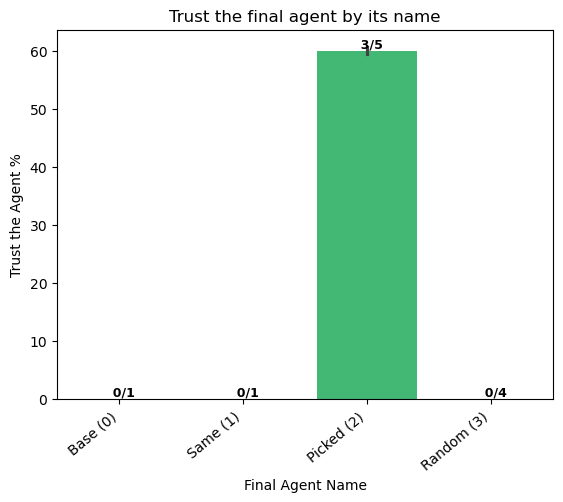

In [ ]:
sub_models_list = [
 'OnlyGreenLL_0429',
 'OnlyBlueLL_0625',
 'AllColorsLL1_0526',
 'OnlyBlueLH_0706',
 'AllColorsLH_0617',
 'NoRedLH1_0612']

sub_models_results = user_results[(user_results['final_agent_name'].isin(sub_models_list)) & (user_results['similarity_level'] >= 0)]

sub_models_list = [model for model in sub_models_list if model in sub_models_results['final_agent_name'].unique()]
plot_simple_bar_plot(
    sub_models_results,
    x_col='final_agent_name',
    y_col='Trust_the_agent',
    levels_names=levels_names, #[agent_name[:-5] for agent_name in user_results['final_agent_name'].unique()],
    figsize=(10, 6),
    estimator=lambda x: np.mean(x) * 100,
    errorbar='sd',
    palette=colors_palette,
    title='Trust the final agent by its name',
    x_label='Final Agent Name',
    y_label='Trust the Agent %',
    order=sub_models_list,
)



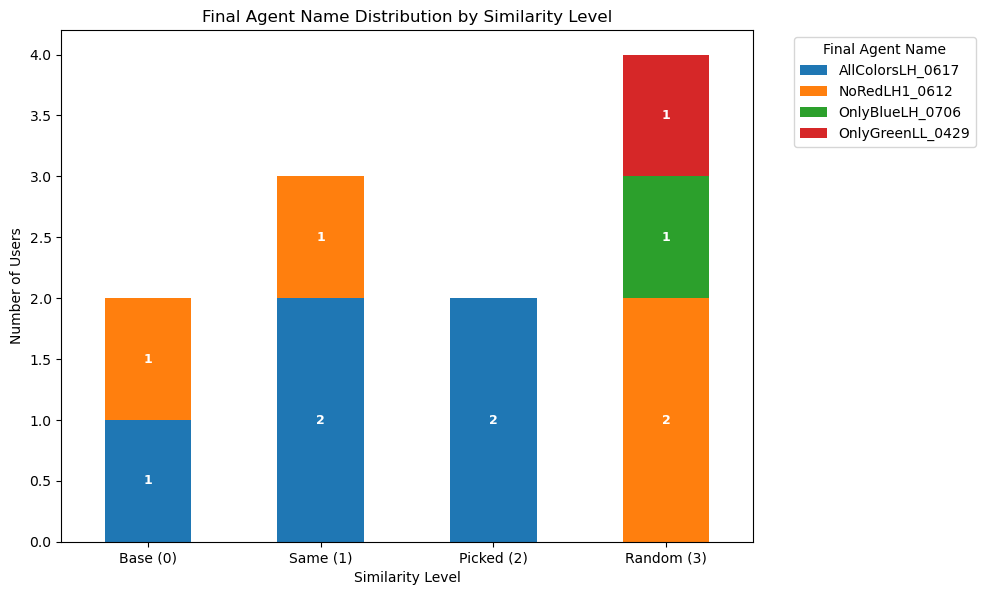

In [ ]:
import matplotlib.pyplot as plt

# Get counts of final_agent_name per similarity_level
agent_counts = user_results.groupby('similarity_level')['final_agent_name'].value_counts().unstack(fill_value=0)

# Plot
agent_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Similarity Level')
plt.ylabel('Number of Users')
plt.title('Final Agent Name Distribution by Similarity Level')
plt.legend(title='Final Agent Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax = plt.gca()
ax.set_xticklabels(levels_names)
plt.xticks(rotation=0, ha='center')
# Annotate each block with the number of users for each final agent
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2),
                        xytext=(0, 0),
                        textcoords="offset points",
                        ha='center', va='center', fontsize=9, fontweight='bold', color='white')
plt.show()

[0, 1, 2, 3]


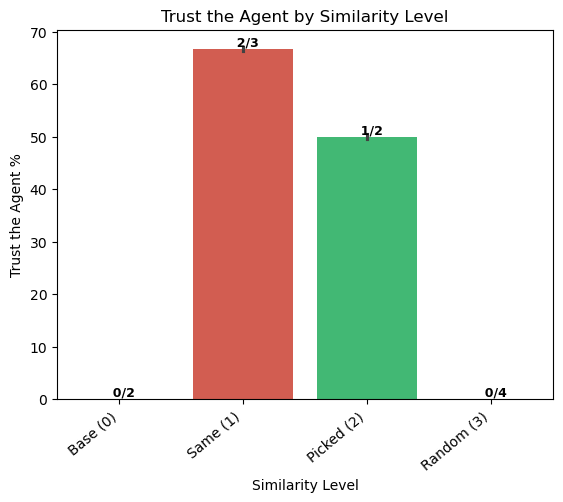

In [ ]:
plot_simple_bar_plot(
    user_results,
    x_col='similarity_level',
    y_col='Trust_the_agent',
    levels_names=levels_names,
    figsize=(8, 6),
    estimator=lambda x: np.mean(x) * 100,
    errorbar='se',
    palette=colors_palette,
    title='Trust the Agent by Similarity Level',
    x_label='Similarity Level',
    y_label='Trust the Agent %',
)

[0, 1, 2, 3]


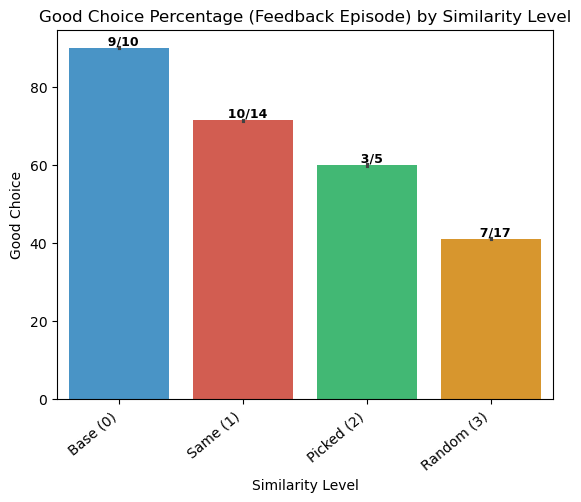

In [ ]:
plot_simple_bar_plot(choice_results, 
                     'similarity_level', 
                     'good_choice_last', 
                     title='Good Choice Percentage (Feedback Episode) by Similarity Level', 
                     palette=colors_palette,
                     levels_names=levels_names)

In [ ]:
choice_results[choice_results['similarity_level'] == 3][['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'feedback_board_index',]]

,user_id,episode,similarity_level,Trust_the_agent,feedback_score,prev_agent,update_agent,prev_agent_mean_score,update_agent_mean_score,prev_agent_last_score,update_agent_last_score,choice,good_choice,good_choice_last,choice_time,board_index
5,55e876f25e4d360012cc283d,1,3,0,7.0,AllColorsLL1_0526,OnlyBlueLH_0706,6.48,8.84,4.4,11.1,0.0,0.0,0.0,38.0,11.0
6,55e876f25e4d360012cc283d,2,3,0,8.0,AllColorsLL1_0526,OnlyBlueLH_0706,6.48,8.84,5.6,11.4,1.0,1.0,1.0,19.0,7.0
7,55e876f25e4d360012cc283d,3,3,0,1.0,OnlyBlueLH_0706,AllColorsLH_0617,8.84,9.39,7.7,9.3,1.0,1.0,1.0,17.0,10.0
8,55e876f25e4d360012cc283d,5,3,0,2.0,AllColorsLH_0617,OnlyBlueLH_0706,9.39,8.84,9.1,8.6,1.0,0.0,0.0,21.0,9.0
9,5bce39ceb8bc680001c67555,1,3,0,3.0,AllColorsLL1_0526,AllColorsLH_0617,6.48,9.39,4.1,9.8,1.0,1.0,1.0,72.0,6.0
10,5bce39ceb8bc680001c67555,2,3,0,2.0,AllColorsLH_0617,OnlyBlueLH_0706,9.39,8.84,6.1,9.5,0.0,1.0,0.0,48.0,19.0
11,5bce39ceb8bc680001c67555,3,3,0,1.0,AllColorsLH_0617,NoRedLH1_0612,9.39,10.87,9.3,9.7,1.0,1.0,1.0,30.0,4.0
31,5ea9a6a68db51d0dfd2edfe2,1,3,0,1.0,AllColorsLL1_0526,OnlyBlueLH_0706,6.48,8.84,3.7,11.4,0.0,0.0,0.0,108.0,5.0
32,5ea9a6a68db51d0dfd2edfe2,2,3,0,3.0,AllColorsLL1_0526,OnlyBlueLL_0625,6.48,7.49,9.3,7.6,1.0,1.0,0.0,63.0,13.0
33,5ea9a6a68db51d0dfd2edfe2,3,3,0,1.0,OnlyBlueLL_0625,AllColorsLH_0617,7.49,9.39,2.7,7.8,1.0,1.0,1.0,53.0,4.0


In [ ]:
choice_results.groupby('similarity_level').agg(total_choices=('choice', 'count'), good_choices=('good_choice_last', 'sum'))

,total_choices,good_choices
similarity_level,,
0,10,9.0
1,14,10.0
2,5,3.0
3,17,7.0


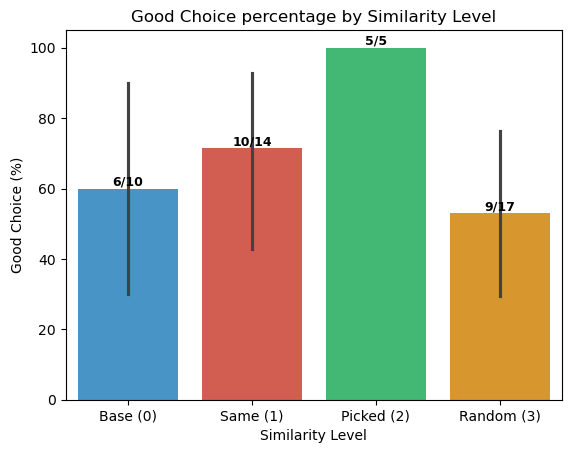

In [ ]:
#basic plot example
ax = sns.barplot(
    data=choice_results,
    x='similarity_level',
    y='good_choice',
    estimator=lambda x: np.mean(x) * 100,  # Convert to percentage
    palette=colors_palette
)

# Compute counts per similarity level once
counts = (
    choice_results
    .groupby('similarity_level')['good_choice']
    .agg(total='size', good='sum')
    .reindex(sorted(choice_results['similarity_level'].unique()))
)

# Build labels in the same left-to-right order as bars
levels_in_plot = list(counts.index)
labels = [f"{int(counts.loc[level, 'good'])}/{int(counts.loc[level, 'total'])}" for level in levels_in_plot]

# Annotate all the bars in the plot
for container, label in zip(ax.containers, labels):
    ax.bar_label(container, labels=[label] * len(container), label_type='edge', fontsize=9, fontweight='bold')

plt.xlabel('Similarity Level')
plt.ylabel('Good Choice (%)')
plt.title('Good Choice percentage by Similarity Level')
ax.set_xticklabels(levels_names)

plt.show()

[0, 1, 2, 3]


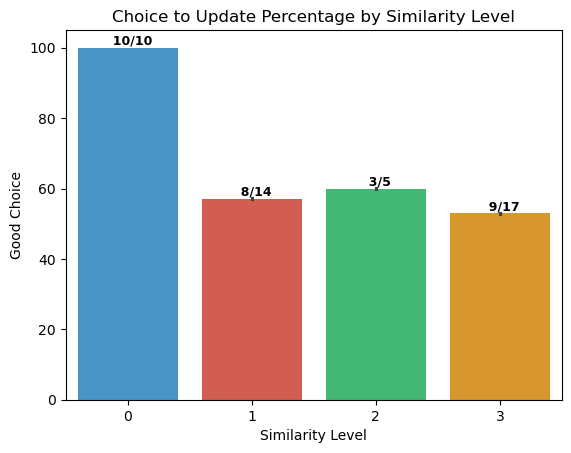

In [ ]:
plot_simple_bar_plot(choice_results, 
                     'similarity_level', 
                     'choice', 
                     title='Choice to Update Percentage by Similarity Level', 
                     palette=colors_palette)

[0, 1, 2, 3]


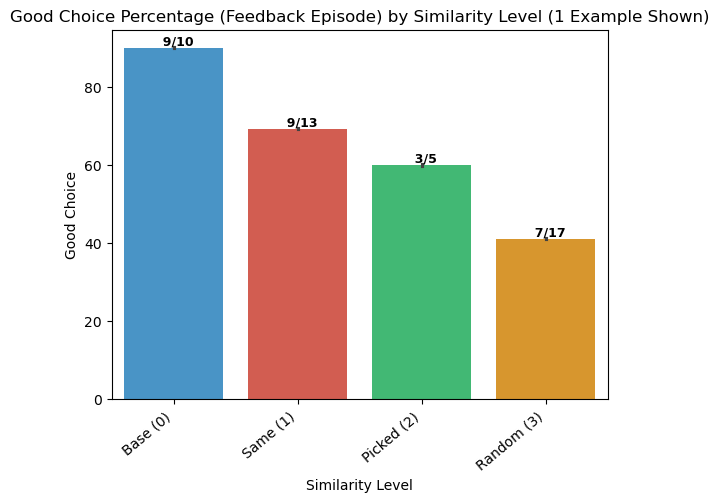

In [ ]:
# only choices that show 1 example
plot_df = choice_results[choice_results['examples_shown'] < 2]
plot_simple_bar_plot(plot_df, 
                     'similarity_level', 
                     'good_choice_last', 
                     title='Good Choice Percentage (Feedback Episode) by Similarity Level (1 Example Shown)',
                     palette=colors_palette,
                     levels_names=levels_names,)


In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score'],
      dtype='object')

                        total        good      
improved_from_prev_mean False True  False True 
board_index                                    
7.0                       NaN   3.0   NaN   3.0
9.0                       2.0   4.0   0.0   3.0
19.0                      2.0   1.0   1.0   1.0
10.0                      1.0   4.0   1.0   2.0
12.0                      2.0   NaN   1.0   NaN
11.0                      5.0   1.0   2.0   0.0
6.0                       NaN   2.0   NaN   2.0
4.0                       2.0   3.0   1.0   3.0
8.0                       NaN   1.0   NaN   1.0
13.0                      NaN   2.0   NaN   1.0
5.0                       NaN   3.0   NaN   2.0
18.0                      1.0   1.0   1.0   0.0
15.0                      NaN   2.0   NaN   2.0
1.0                       NaN   2.0   NaN   1.0
14.0                      1.0   NaN   1.0   NaN
3.0                       NaN   1.0   NaN   1.0


                        total        good      
improved_from_prev_mean False True  False True 
board_index                                    
7.0                       NaN   3.0   NaN   3.0
9.0                       2.0   4.0   0.0   3.0
19.0                      2.0   1.0   1.0   1.0
10.0                      1.0   4.0   1.0   2.0
12.0                      2.0   NaN   1.0   NaN
11.0                      5.0   1.0   2.0   0.0
6.0                       NaN   2.0   NaN   2.0
4.0                       2.0   3.0   1.0   3.0
8.0                       NaN   1.0   NaN   1.0
13.0                      NaN   2.0   NaN   1.0
5.0                       NaN   3.0   NaN   2.0
18.0                      1.0   1.0   1.0   0.0
15.0                      NaN   2.0   NaN   2.0
1.0                       NaN   2.0   NaN   1.0
14.0                      1.0   NaN   1.0   NaN
3.0                       NaN   1.0   NaN   1.0


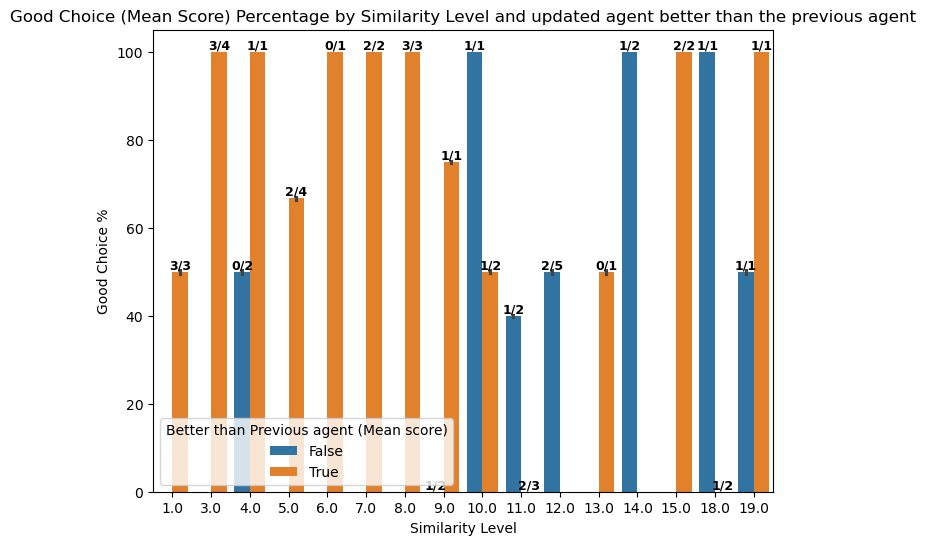

In [ ]:

hue = 'improved_from_prev_mean'
plot_data = choice_results[(choice_results['episode'] >= 1) ].copy() #&(choice_results['improved_from_base_last'] != 0)
# plot_data[hue] = plot_data[hue].replace(0, 1)

plot_grouped_barplot(plot_data, 
                     x_col='feedback_board_index', 
                     y_col='good_choice', 
                     hue=hue, 
                     title='Good Choice (Mean Score) Percentage by Similarity Level and updated agent better than the previous agent',# (only in the first episode)',
                    #  levels_names=levels_names, 
                     estimator=lambda x: np.mean(x) * 100, 
                     errorbar='se')

In [ ]:
choice_results[(choice_results['similarity_level'] == 0) & (choice_results['improved_from_base_last'] == -1)]

,user_id,episode,similarity_level,Trust_the_agent,feedback_score,prev_agent,update_agent,prev_agent_mean_score,update_agent_mean_score,prev_agent_last_score,...,good_choice_last,choice_time,examples_shown,board_index,improved_from_base,improved_from_base_last,improved_from_prev_last,improved_from_prev_mean,final_agent,final_agent_score


In [ ]:
# # Helper: annotate grouped bars with dataset counts per (x, hue)
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# plot_data = choice_results[choice_results['episode'] == 1].copy()

# # Example usage with your current DataFrame and grouping
# hue_col = 'improved_from_base'
# plt.figure(figsize=(8, 6))
# ax = sns.barplot(data=plot_data,
#                   x='similarity_level', y='good_choice',
#                   hue=hue_col, 
#                   estimator=lambda x: np.mean(x) * 100,
#                   errorbar='se')

# hue_values = ax.get_legend_handles_labels()[1]


# # Compute counts per similarity level and hue
# counts = (
#     plot_data
#     .groupby(['similarity_level', hue_col])['good_choice']
#     .agg(total='size', good='sum')
#     .reset_index()
#     .pivot(index='similarity_level', columns=hue_col, values=['total', 'good'])
# )
# print(counts)

# # Build labels in the same left-to-right order as bars
# levels_in_plot = list(counts.index)
# # Build labels as a flat list for each bar in the order they appear
# labels = []
# for improvement in counts['good'].columns:
#     level_labels = []
    
#     for level in levels_in_plot:
#         good = counts['good'].get(improvement, {}).get(level, None)
#         total = counts['total'].get(improvement, {}).get(level, None)
#         # Check for NaN using pandas.isna
#         if not pd.isna(good) and not pd.isna(total):
#             level_labels.append(f"{int(good)}/{int(total)}")

#     labels.append(level_labels)

# print(labels)
# # Annotate all the bars in the plot
# for container, level_labels in zip(ax.containers, labels):
#     print(level_labels)
#     ax.bar_label(container, labels=level_labels, label_type='edge', fontsize=9, fontweight='bold')


# ax.set_xticklabels(levels_names)
# plt.title("User Choices Analysis")
# plt.xlabel("Similarity Level")
# plt.ylabel("Good Choice (%)")

# plt.legend(title=hue_col)
# plt.show()

In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score'],
      dtype='object')

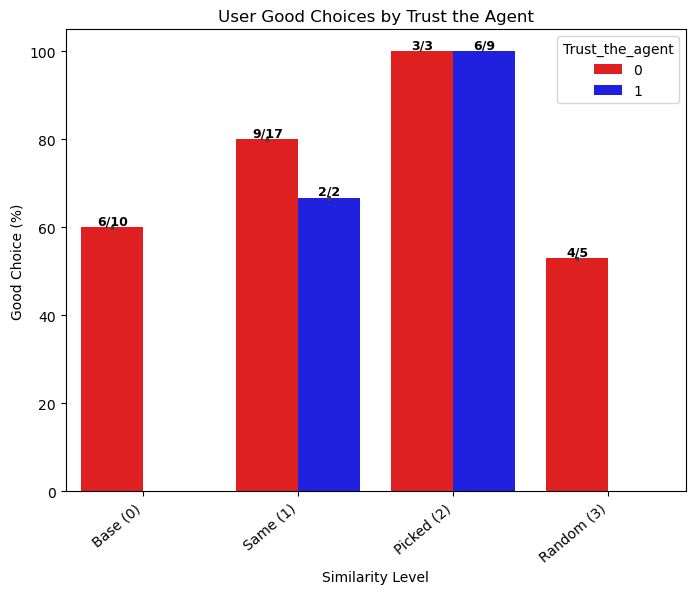

In [ ]:
plot_grouped_barplot(df=choice_results,
                     x_col='similarity_level', 
                     y_col='good_choice',
                     hue='Trust_the_agent',
                     levels_names=levels_names,
                     palette=['red', 'blue'],
                     title="User Good Choices by Trust the Agent",
                     xlabel="Similarity Level",
                     ylabel="Good Choice (%)"
                    )

### Choices times

[0, 1, 2, 3]


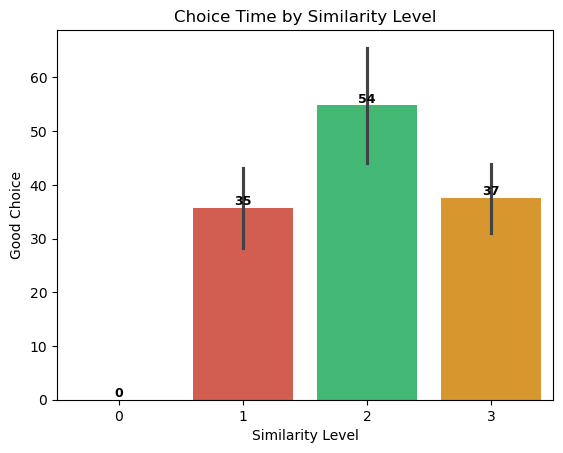

In [ ]:
# choice time by similarity level
plot_simple_bar_plot(choice_results, 
                     'similarity_level', 
                     'choice_time', 
                     title='Choice Time by Similarity Level', 
                     aggfunc='mean', 
                     from_total_agg=False,
                     estimator=lambda x: np.mean(x),  # Convert to percentage
                     palette=colors_palette,
                     errorbar='se'
)

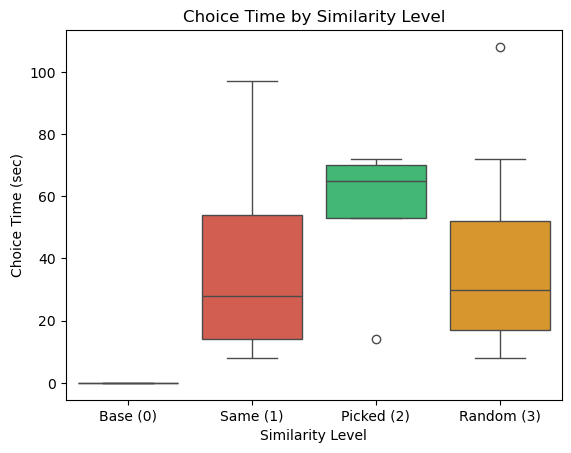

In [ ]:


ax = sns.boxplot(
    data=choice_results[choice_results['choice_time'] < 200], # filter out extreme values
    x='similarity_level',
    y='choice_time',
    palette=colors_palette  # Use the predefined color palette for the box plot
)
plt.xlabel('Similarity Level')
plt.ylabel('Choice Time (sec)')
plt.title('Choice Time by Similarity Level')
ax.set_xticklabels(levels_names)


plt.show()

### Trust the Agent

[0, 1, 2, 3]


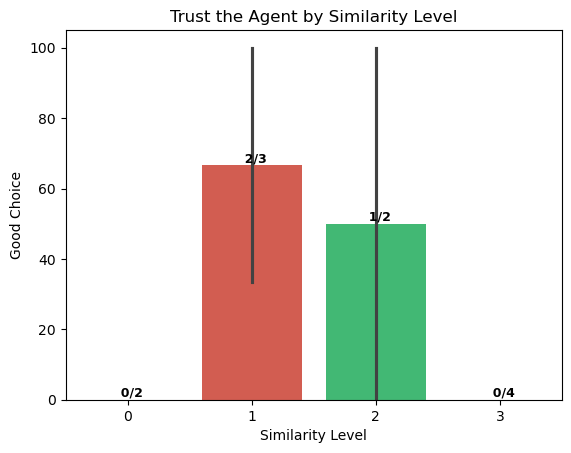

In [ ]:
plot_simple_bar_plot(user_results,
                     'similarity_level',
                     'Trust_the_agent',
                     title='Trust the Agent by Similarity Level',
                     aggfunc='sum',
                     from_total_agg=True,
                     estimator=lambda x: np.mean(x) * 100,
                     palette=colors_palette,
                     errorbar=('ci', 70)
                     )


In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score'],
      dtype='object')

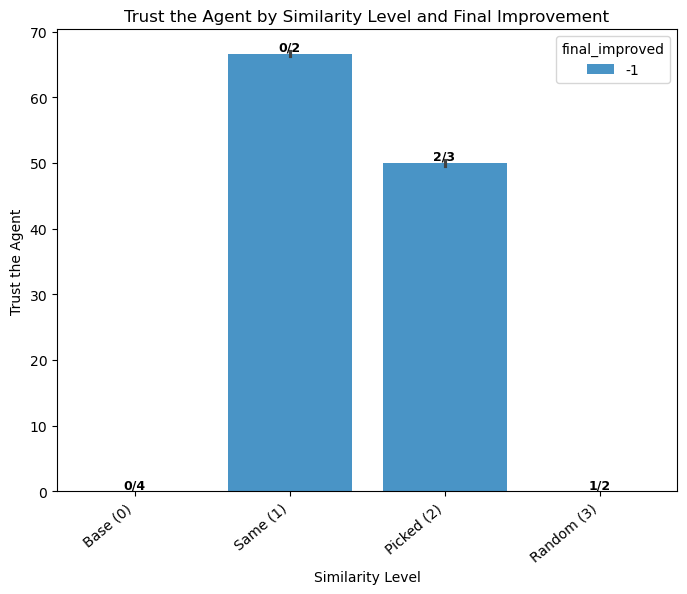

In [ ]:
plot_grouped_barplot(user_results,
                     'similarity_level',
                     'Trust_the_agent',
                     hue='final_improved',
                     estimator=lambda x: np.mean(x) * 100,
                     palette=colors_palette,
                     xlabel='Similarity Level',
                     ylabel='Trust the Agent',
                     title='Trust the Agent by Similarity Level and Final Improvement',
                     levels_names=levels_names,
                     from_total_agg=True,
                     )

In [ ]:
user_results.columns

Index(['user_id', 'similarity_level', 'Trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_good_choices',
       'number_of_good_choices_last', 'number_of_improved_choices',
       'final_improved', 'final_agent_score', 'final_agent_name',
       'final_agent_final_part_score', 'user_performance', 'age', 'gender',
       'education', 'familiarity_with_AI', 'AI_1', 'AI_2', 'AI_3', 'AI_4',
       'AI_5'],
      dtype='object')

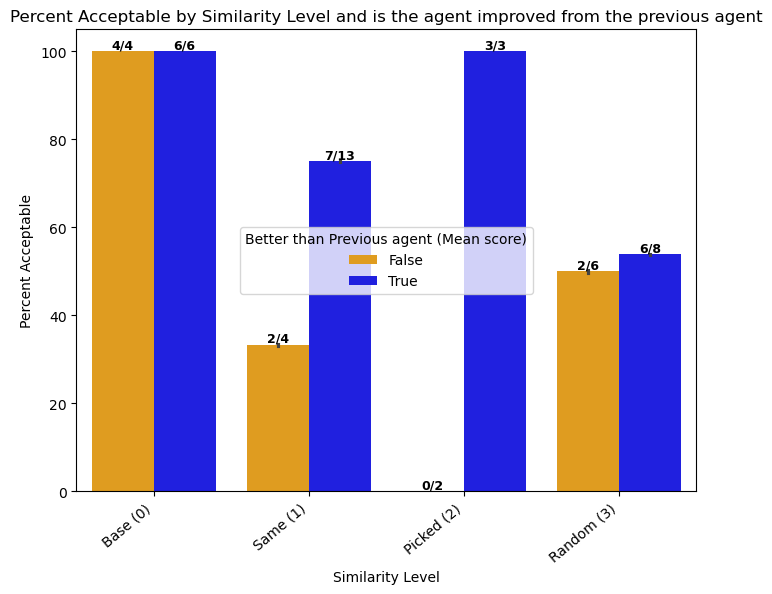

In [ ]:
# trust by the number of improved from improved_from_prev_last
plot_df = choice_results.copy()
# plot_df['percent_acceptable'] = plot_df['number_of_accepts'] / plot_df['number_of_choices']
plot_grouped_barplot(plot_df,
                     x_col='similarity_level',
                     y_col='choice',
                     hue='improved_from_prev_mean',
                     estimator=lambda x: np.mean(x) *100,
                     errorbar='se',
                     palette=['orange', 'blue'],  #colors_palette,
                     xlabel='Similarity Level',
                     ylabel='Percent Acceptable',
                     from_total_agg=True,
                     levels_names=levels_names,
                     aggfunc='sum',
                     title='Percent Acceptable by Similarity Level and is the agent improved from the previous agent'
                     )

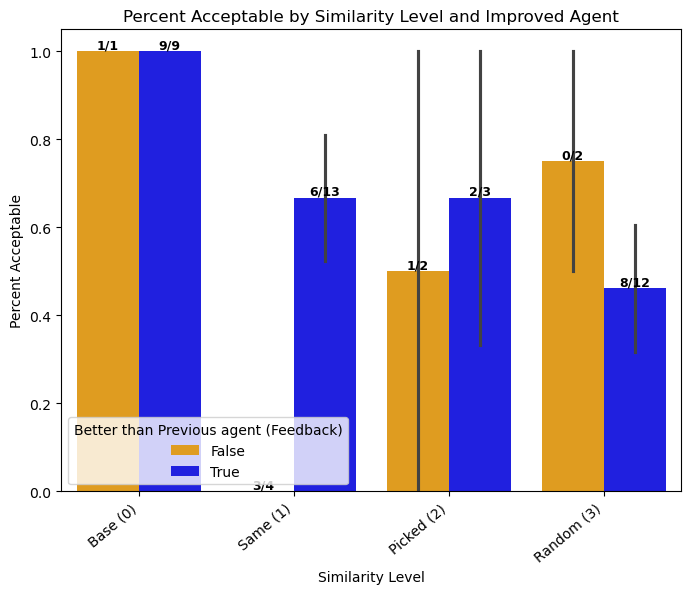

In [ ]:
# percent acceptable by the number similarity level and improved agent

plot_grouped_barplot(choice_results,
                     x_col='similarity_level',
                     y_col='choice',
                     hue='improved_from_prev_last',
                     estimator=lambda x: np.mean(x),
                     errorbar='se',
                     palette=['orange', 'blue'],  #colors_palette,
                     xlabel='Similarity Level',
                     ylabel='Percent Acceptable',
                     from_total_agg=True,
                     levels_names=levels_names,
                     aggfunc='sum',
                     title='Percent Acceptable by Similarity Level and Improved Agent'
                     )

In [ ]:
bad_choices = choice_results[choice_results['good_choice'] == 0]
bad_choices['choice'].value_counts()



choice
1.0    8
0.0    8
Name: count, dtype: int64

[1.0, 2.0, 3.0, 4.0, 5.0]


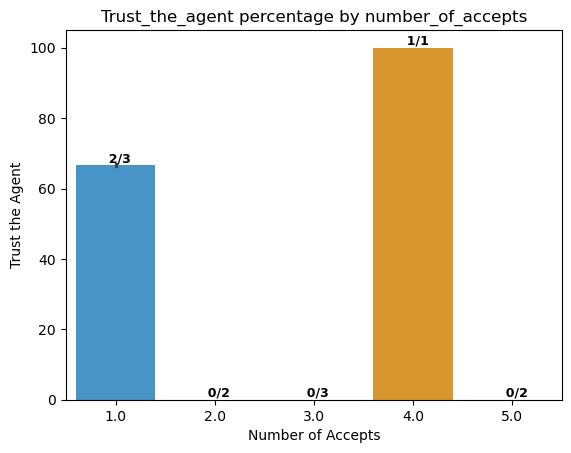

In [ ]:
# trust by the number of improved from num choices

plot_simple_bar_plot(user_results[user_results['number_of_improved_choices'] >= 0],
                     x_col='number_of_accepts',
                     y_col='Trust_the_agent',
                     estimator=lambda x: np.mean(x) * 100,
                     errorbar='se',
                     palette=colors_palette,
                     x_label='Number of Accepts',
                     y_label='Trust the Agent',
                     from_total_agg=True,
                     levels_names=None,)


['2', '3', '4. Neither agree nor disagree', '5', '6', '7. Strongly agree']


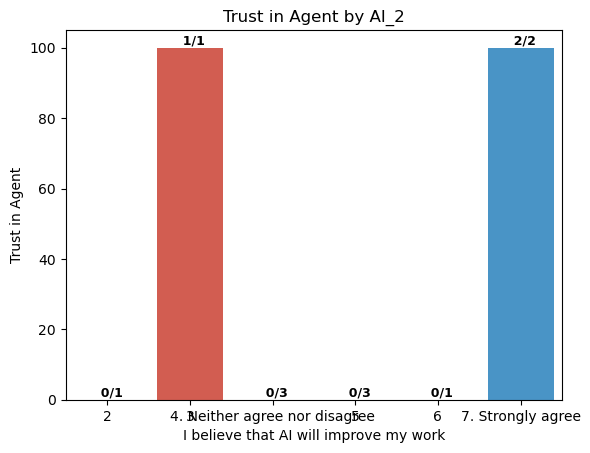

In [ ]:
user_features = ['gender', 'age', 'education', 'familiarity_with_AI', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5']
i = 5
plot_simple_bar_plot(df=user_results,
                     y_col='Trust_the_agent',
                     x_col=user_features[i],
                     levels_names=None,
                     palette=colors_palette,
                     x_label=ai_questions_map[user_features[i]],
                     y_label='Trust in Agent',
                     title=f'Trust in Agent by {user_features[i]}')



In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score'],
      dtype='object')

[0, 1, 2, 3]


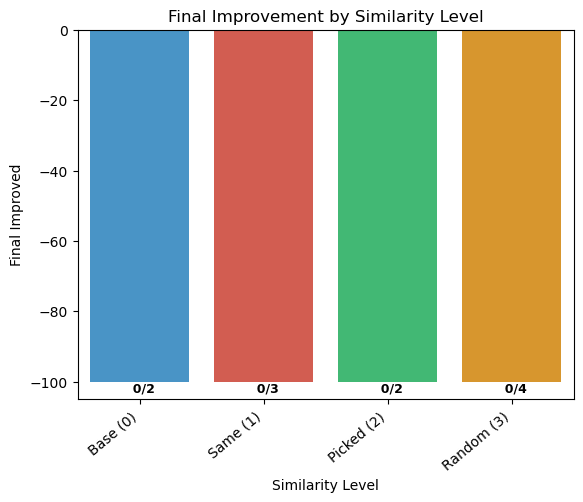

In [ ]:
# improved_from_base but only the last episode
plot_simple_bar_plot(user_results,
                     x_col='similarity_level',
                     y_col='final_improved',
                     y_label='Final Improved',
                     x_label='Similarity Level',
                     title='Final Improvement by Similarity Level',
                     palette=colors_palette,
                     levels_names=levels_names,
                     aggfunc=lambda x: (x == 1).sum(),
                     )

### Agent diff in Score

['[-5,-1)', '[-1,0)', '[0,0.5)', '[0.5,3)', '[3,10)']
Categories (8, object): ['(,-10)' < '[-10,-5)' < '[-5,-1)' < '[-1,0)' < '[0,0.5)' < '[0.5,3)' < '[3,10)' < '[10,)']
['[-1,0)', '[-5,-1)', '[0,0.5)', '[0.5,3)', '[3,10)']


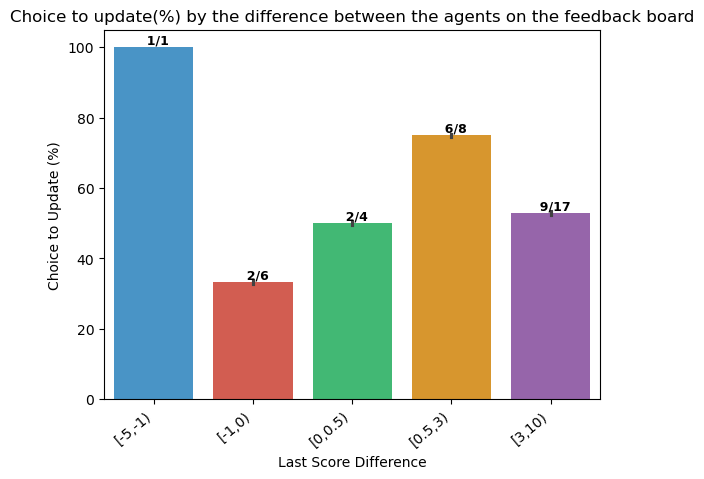

In [ ]:
plot_df = choice_results[choice_results['similarity_level'] >= 1].copy()
plot_df['last_score_diff'] = round(plot_df['update_agent_last_score'] - plot_df['prev_agent_last_score'], 0)
plot_df['mean_score_diff'] = round(plot_df['update_agent_mean_score'] - plot_df['prev_agent_mean_score'], 0)

# Define bins and labels
bins = [-float('inf'), -10, -5, -1, 0, 0.5, 3, 10, float('inf')]
labels = ['(,-10)', '[-10,-5)', '[-5,-1)', '[-1,0)', '[0,0.5)', '[0.5,3)', '[3,10)', '[10,)']

# Apply binning
plot_df['last_score_diff_bin'] = pd.cut(plot_df['last_score_diff'], bins=bins, labels=labels, right=False)

# Filter for similarity_level > 0
plot_df = plot_df[plot_df['similarity_level']  > 0]

# Sort by bins
plot_df = plot_df.sort_values(by='last_score_diff_bin')

print(plot_df['last_score_diff_bin'].unique())

plot_simple_bar_plot(plot_df,
                     x_col='last_score_diff_bin',
                     y_col='choice', 
                    #  y_col='good_choice_last',
                    #  title='Good Choice (Feedback Board) Percentage by the difference between the agents on the feedback board' ,
                     y_label="Choice to Update (%)",
                     title='Choice to update(%) by the difference between the agents on the feedback board',
                     estimator=lambda x: np.mean(x) * 100,
                     aggfunc='sum',
                     from_total_agg=True,
                     levels_names=plot_df['last_score_diff_bin'].unique(),
                     x_label='Last Score Difference',
                     palette=colors_palette,
                     errorbar='sd'
                     )



['AllColorsLH_0617', 'AllColorsLL1_0526', 'NoRedLH1_0612', 'OnlyBlueLH_0706', 'OnlyBlueLL_0625', 'OnlyGreenLL_0429']


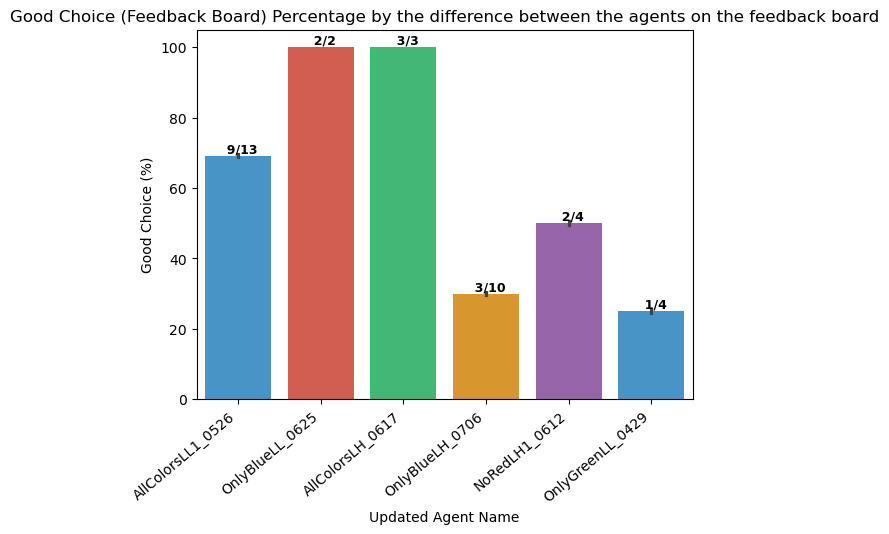

In [ ]:
# Choice to update(%) by the updated agent name
plot_simple_bar_plot(plot_df,
                     x_col='update_agent',
                    #  y_col='choice', 
                     y_col='good_choice_last',
                     title='Good Choice (Feedback Board) Percentage by the difference between the agents on the feedback board' ,
                    #  y_label="Choice to Update (%)",
                    y_label="Good Choice (%)",
                    #  title='Choice to update(%) by the updated agent name',
                     estimator=lambda x: np.mean(x) * 100,
                     aggfunc='sum',
                     from_total_agg=True,
                     levels_names=list(choice_results['update_agent'].unique()),
                     x_label='Updated Agent Name',
                     palette=colors_palette,
                     errorbar='sd'
                     )

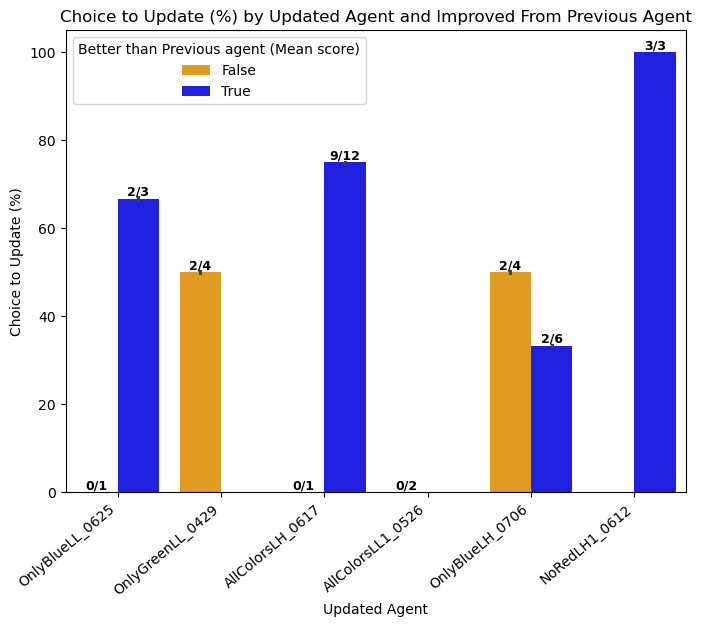

In [ ]:
plot_grouped_barplot(plot_df,
                     x_col='update_agent',
                    #  y_col='good_choice',
                     y_col='choice',
                     ylabel="Choice to Update (%)",
                    #  ylabel="Good Choice (%)",
                     xlabel="Updated Agent",
                     hue='improved_from_prev_mean',
                     from_total_agg=True,
                     aggfunc='sum',
                     levels_names=list(plot_df['update_agent'].unique()),
                     title='Choice to Update (%) by Updated Agent and Improved From Previous Agent',
                     palette=['orange', 'blue'],
)


In [ ]:
plot_df['mean_score_diff'].value_counts().sort_index()

mean_score_diff
-5.0    4
-4.0    1
-3.0    2
-1.0    5
 1.0    8
 2.0    8
 3.0    3
 6.0    1
 8.0    4
Name: count, dtype: int64

['(,-1)', '[-1,-0.1)', '[1,2)', '[2,)']
Categories (6, object): ['(,-1)' < '[-1,-0.1)' < '[-0.1,0.1)' < '[0.1,1)' < '[1,2)' < '[2,)']
['(,-1)', '[-1,-0.1)', '[1,2)', '[2,)']


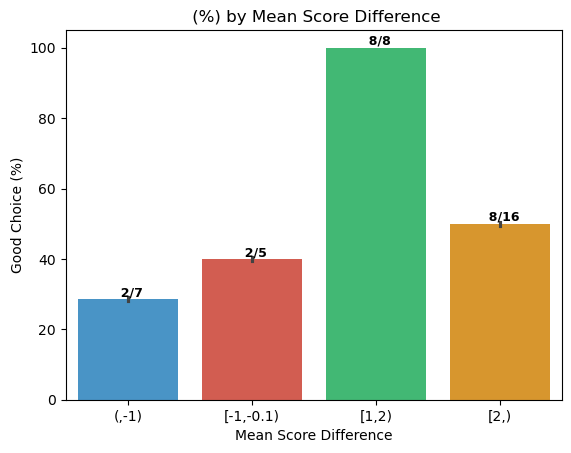

In [ ]:
plot_df = choice_results[choice_results['similarity_level'] >= 1].copy()
plot_df['last_score_diff'] = round(plot_df['update_agent_last_score'] - plot_df['prev_agent_last_score'], 0)
plot_df['mean_score_diff'] = round(plot_df['update_agent_mean_score'] - plot_df['prev_agent_mean_score'], 0)

# Define bins and labels
bins = [-float('inf'), -1, -0.1, 0.1, 1, 2, float('inf')]
labels = ['(,-1)', '[-1,-0.1)', '[-0.1,0.1)', '[0.1,1)', '[1,2)', '[2,)']

# Apply binning
plot_df['mean_score_diff_bin'] = pd.cut(plot_df['mean_score_diff'], bins=bins, labels=labels, right=False)

# Filter for similarity_level > 0
plot_df = plot_df[plot_df['similarity_level'] > 0]

# Sort by bins
plot_df = plot_df.sort_values(by='mean_score_diff_bin')

print(plot_df['mean_score_diff_bin'].unique())

plot_simple_bar_plot(plot_df,
                     x_col='mean_score_diff_bin',
                     y_col='choice',
                     title=' (%) by Mean Score Difference' ,#'Choice to update percentage by Last Score Difference',
                     estimator=lambda x: np.mean(x) * 100,
                     aggfunc='sum',
                     from_total_agg=True,
                     levels_names=plot_df['mean_score_diff_bin'].unique(),
                     x_label='Mean Score Difference',
                    #  y_label='Choice to Update (%)',
                    y_label='Good Choice (%)',
                     palette=colors_palette,
                     errorbar='sd'
                     )


In [ ]:
print(labels[5])
plot_df[plot_df['mean_score_diff_bin'] == labels[5]]['prev_agent'].value_counts()

[2,)


prev_agent
AllColorsLL1_0526    9
OnlyGreenLL_0429     5
OnlyBlueLL_0625      2
Name: count, dtype: int64

In [ ]:
for label in labels:
    print(label)
    print(plot_df[plot_df['mean_score_diff_bin'] == label][['prev_agent', 'update_agent']].value_counts())

(,-1)
prev_agent         update_agent     
AllColorsLL1_0526  OnlyGreenLL_0429     4
AllColorsLH_0617   AllColorsLL1_0526    1
NoRedLH1_0612      AllColorsLL1_0526    1
                   OnlyBlueLL_0625      1
Name: count, dtype: int64
[-1,-0.1)
prev_agent        update_agent    
AllColorsLH_0617  OnlyBlueLH_0706     4
NoRedLH1_0612     AllColorsLH_0617    1
Name: count, dtype: int64
[-0.1,0.1)
Series([], Name: count, dtype: int64)
[0.1,1)
Series([], Name: count, dtype: int64)
[1,2)
prev_agent         update_agent    
AllColorsLH_0617   NoRedLH1_0612       3
OnlyBlueLH_0706    AllColorsLH_0617    3
AllColorsLL1_0526  OnlyBlueLL_0625     2
Name: count, dtype: int64
[2,)
prev_agent         update_agent    
AllColorsLL1_0526  OnlyBlueLH_0706     6
OnlyGreenLL_0429   AllColorsLH_0617    4
AllColorsLL1_0526  AllColorsLH_0617    3
OnlyBlueLL_0625    AllColorsLH_0617    2
OnlyGreenLL_0429   OnlyBlueLL_0625     1
Name: count, dtype: int64


In [ ]:
pairs_by_sim_level = {sim_level: [] for sim_level in choice_results['similarity_level'].unique()}

           prev_agent       update_agent  good_choice_percent  n  \
0    AllColorsLH_0617  AllColorsLL1_0526             1.000000  1   
1    AllColorsLH_0617      NoRedLH1_0612             1.000000  3   
2    AllColorsLH_0617    OnlyBlueLH_0706             0.500000  4   
3   AllColorsLL1_0526   AllColorsLH_0617             1.000000  3   
4   AllColorsLL1_0526    OnlyBlueLH_0706             0.333333  6   
5   AllColorsLL1_0526    OnlyBlueLL_0625             1.000000  2   
6   AllColorsLL1_0526   OnlyGreenLL_0429             0.500000  4   
7       NoRedLH1_0612   AllColorsLH_0617             1.000000  1   
8       NoRedLH1_0612  AllColorsLL1_0526             1.000000  1   
9       NoRedLH1_0612    OnlyBlueLL_0625             1.000000  1   
10    OnlyBlueLH_0706   AllColorsLH_0617             1.000000  3   
11    OnlyBlueLL_0625   AllColorsLH_0617             1.000000  2   
12   OnlyGreenLL_0429   AllColorsLH_0617             0.250000  4   
13   OnlyGreenLL_0429    OnlyBlueLL_0625        

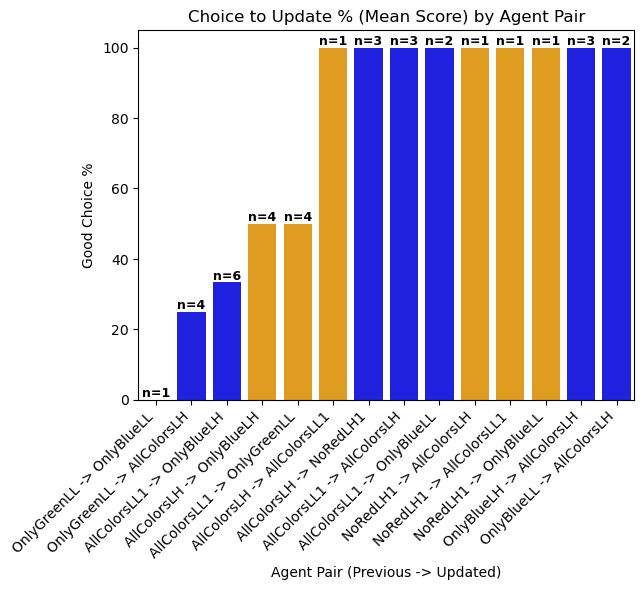

In [ ]:
# Calculate good_choice percent for each (prev_agent, update_agent) pair
sim_level = 1
# plot_df = choice_results[choice_results['similarity_level'] == sim_level].copy()
plot_df = choice_results[(choice_results['prev_agent'] != choice_results['update_agent']) & (choice_results['similarity_level'] >= sim_level)].copy()
pairwise_good_choice = (
    plot_df
    .groupby(['prev_agent', 'update_agent'])['good_choice']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'good_choice_percent', 'count': 'n'})
)

pairwise_good_choice['improved_from_prev_mean'] = pairwise_good_choice.apply(
    lambda row: models_mean_scores.get(row['update_agent'], 0) > models_mean_scores.get(row['prev_agent'], 0),
    axis=1
)
print(pairwise_good_choice)

# Convert percent to 0-100 scale
pairwise_good_choice['good_choice_percent'] = pairwise_good_choice['good_choice_percent'] * 100
pairwise_good_choice['pair'] = pairwise_good_choice['prev_agent'].str[:-5] + ' -> ' + pairwise_good_choice['update_agent'].str[:-5]
# pairwise_good_choice = pairwise_good_choice[pairwise_good_choice['n'] > 10]  
# Display sorted by percent (descending)
pairwise_good_choice = pairwise_good_choice.sort_values('good_choice_percent', ascending=True)
pairs_by_sim_level[sim_level] = pairwise_good_choice[['pair', 'good_choice_percent', 'n']].values.tolist()
# Set colors: blue if improved_from_prev_mean is True, orange otherwise
bar_colors = ['blue' if val else 'orange' for val in pairwise_good_choice['improved_from_prev_mean']]
print(pairwise_good_choice)

ax = sns.barplot(
    data=pairwise_good_choice, 
    x='pair', 
    y='good_choice_percent', 
    palette=bar_colors
)


labels = [f"n={int(n)}" for n in pairwise_good_choice['n']]
print(labels)
for container, label in zip(ax.containers, labels):
    ax.bar_label(container, labels=[label] * len(container), label_type='edge', fontsize=9, fontweight='bold')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('Choice to Update % (Mean Score) by Agent Pair')
plt.xlabel('Agent Pair (Previous -> Updated)')
# plt.ylabel('Choice to Update %')
plt.ylabel('Good Choice %')
plt.show()


[]


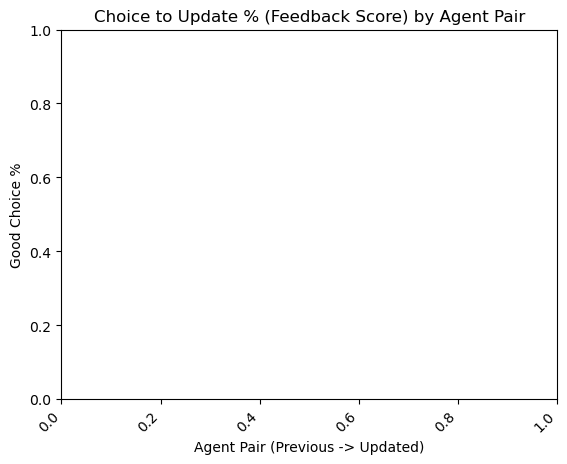

In [ ]:
# Calculate good_choice (Last) percent for each (prev_agent, update_agent) pair
sim_level = 1
# plot_df = choice_results[choice_results['similarity_level'] == sim_level].copy()
plot_df = choice_results[(choice_results['prev_agent'] != choice_results['update_agent']) & (choice_results['similarity_level'] >= sim_level)].copy()
pairwise_good_choice = (
    plot_df
    .groupby(['prev_agent', 'update_agent'])['good_choice_last']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'good_choice_percent', 'count': 'n'})
)

pairwise_good_choice['improved_from_prev_mean'] = pairwise_good_choice.apply(
    lambda row: models_mean_scores.get(row['update_agent'], 0) > models_mean_scores.get(row['prev_agent'], 0),
    axis=1
)

# Convert percent to 0-100 scale
pairwise_good_choice['good_choice_percent'] = pairwise_good_choice['good_choice_percent'] * 100
pairwise_good_choice['pair'] = pairwise_good_choice['prev_agent'].str[:-5] + ' -> ' + pairwise_good_choice['update_agent'].str[:-5]
pairwise_good_choice = pairwise_good_choice[pairwise_good_choice['n'] > 10]  
# Display sorted by percent (descending)
pairwise_good_choice = pairwise_good_choice.sort_values('good_choice_percent', ascending=True)
pairs_by_sim_level[sim_level] = pairwise_good_choice[['pair', 'good_choice_percent', 'n']].values.tolist()
# Set colors: blue if improved_from_prev_mean is True, orange otherwise
bar_colors = ['blue' if val else 'orange' for val in pairwise_good_choice['improved_from_prev_mean']]

ax = sns.barplot(
    data=pairwise_good_choice, 
    x='pair', 
    y='good_choice_percent', 
    palette=bar_colors
)
labels = [f"n={int(n)}" for n in pairwise_good_choice['n']]
print(labels)
for container, label in zip(ax.containers, labels):
    ax.bar_label(container, labels=[label] * len(container), label_type='edge', fontsize=9, fontweight='bold')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('Choice to Update % (Feedback Score) by Agent Pair')
plt.xlabel('Agent Pair (Previous -> Updated)')
# plt.ylabel('Choice to Update %')
plt.ylabel('Good Choice %')
plt.show()


In [ ]:
choice_results[(choice_results['prev_agent'] == "NoRedLH3_0612") & (choice_results['update_agent'] == "AllColorsLH_0617")]['similarity_level'].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
problematic_pairs = {sim_level: [item for item in data if item[1] < 70] for sim_level, data in pairs_by_sim_level.items()}
problematic_pairs

{0: [], 3: [], 2: [], 1: []}

### Board difficulty

In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score'],
      dtype='object')

[0, 1, 2, 3]


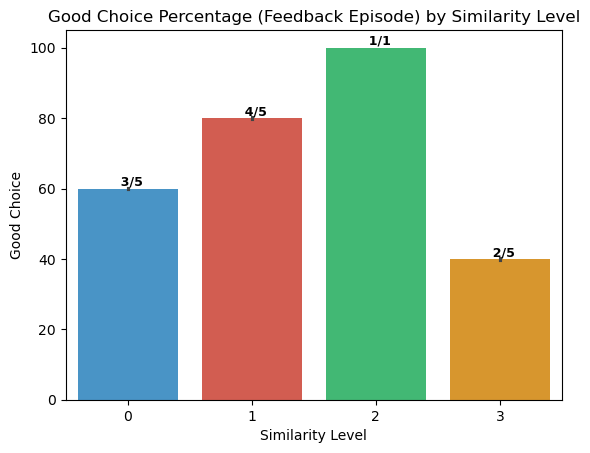

In [ ]:
env_group_map = {1: 0,
 12: 0,
 9: 0,
 8: 0,
 17: 0,
 4: 0,
 18: 1,
 6: 1,
 3: 1,
 2: 1,
 15: 1,
 10: 1,
 7: 2,
 5: 2,
 13: 2,
 11: 2,
 14: 2,
 16: 2}

plot_df = choice_results.copy()
plot_df['board_group'] = plot_df['feedback_board_index'].map(env_group_map)
plot_df = plot_df[plot_df['board_group'] == 0]
plot_simple_bar_plot(plot_df,
                     'similarity_level', 
                     'good_choice', 
                     title='Good Choice Percentage (Feedback Episode) by Similarity Level', 
                     palette=colors_palette)


### Nunmer of Examples

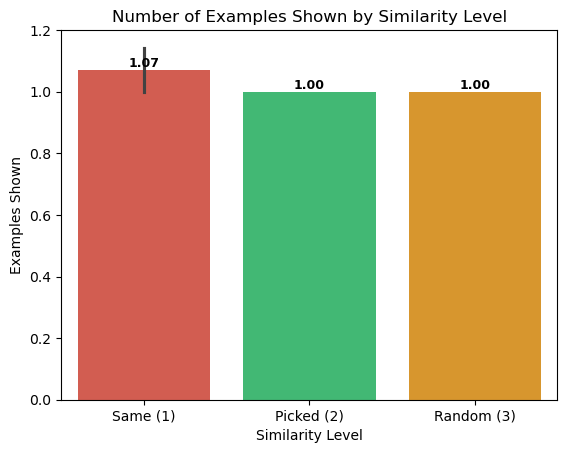

In [ ]:
ax = sns.barplot(
    data=choice_results[choice_results['similarity_level'] > 0],
    x='similarity_level',
    y='examples_shown',
    palette=colors_palette[1:],
    # hue='final_improved',
    estimator= lambda x: np.mean(x),
    errorbar=('ci', 70),
)

for container in ax.containers:
    # Count the number of rows corresponding to each bar
    labels = [f'{bar.get_height():.2f}' for bar in container]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=9, fontweight='bold')

plt.title('Number of Examples Shown by Similarity Level')
plt.xlabel('Similarity Level')
plt.ylabel('Examples Shown')
ax.set_xticklabels(levels_names[1:])
plt.show()

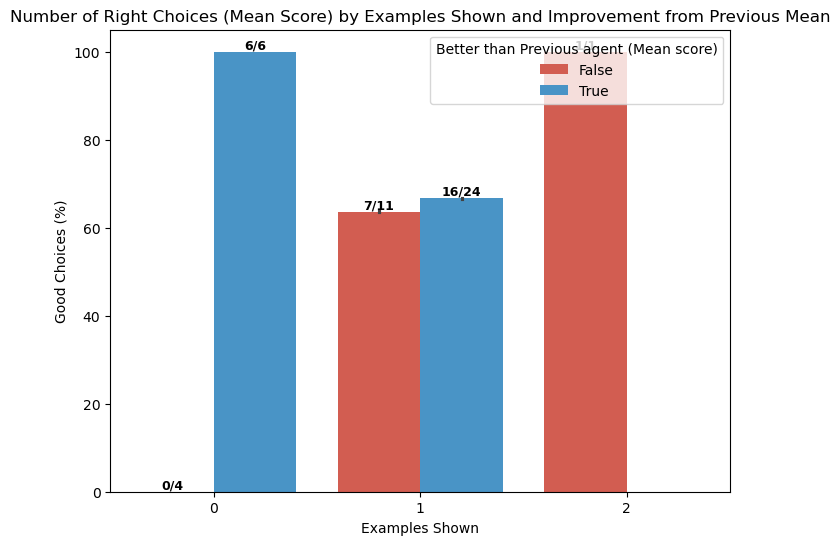

In [ ]:
plot_grouped_barplot(
    df=choice_results,
    x_col='examples_shown',
    y_col='good_choice',
    hue='improved_from_prev_mean',
    title='Number of Right Choices (Mean Score) by Examples Shown and Improvement from Previous Mean',
    xlabel='Examples Shown',
    ylabel='Good Choices (%)',
    levels_names=[str(i) for i in range(int(choice_results['examples_shown'].max()) + 1)],
    aggfunc='sum',
    estimator=lambda x: np.mean(x)*100,
    from_total_agg=True,
    palette=[colors_palette[1], colors_palette[0]]
)

### User performance vs Agent score - Final Part

In [ ]:
user_results.columns

Index(['user_id', 'similarity_level', 'Trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_good_choices',
       'number_of_good_choices_last', 'number_of_improved_choices',
       'final_improved', 'final_agent_score', 'final_agent_name',
       'final_agent_final_part_score', 'user_performance', 'age', 'gender',
       'education', 'familiarity_with_AI', 'AI_1', 'AI_2', 'AI_3', 'AI_4',
       'AI_5'],
      dtype='object')

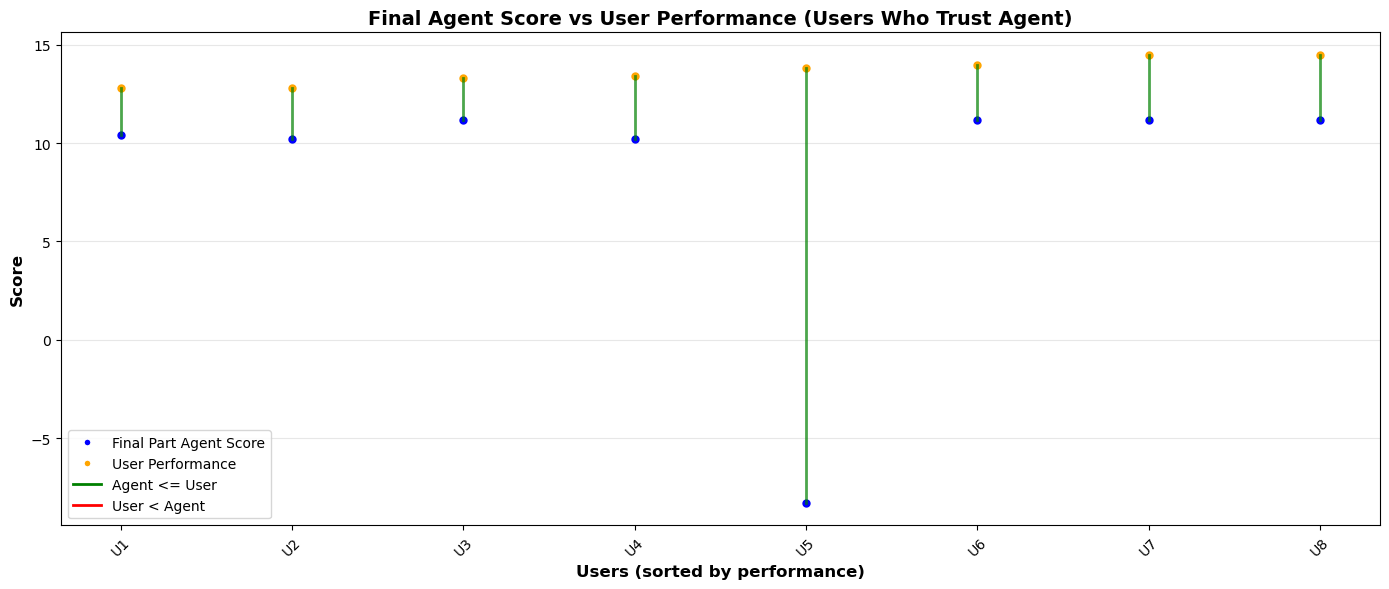

Number of users where agent performed better: 0
Number of users where user performed better or equal: 8


In [ ]:
from matplotlib.lines import Line2D

# Users preference vs the model's performance
trust_users = user_results[user_results['Trust_the_agent'] == 0]

# Create the plot
plt.figure(figsize=(14, 6))

# Calculate the difference between final_agent_score and user_performance
# Sort trust_users by user_performance before calculating differences
trust_users = trust_users.sort_values('user_performance')
differences = trust_users['user_performance'] - trust_users['final_agent_final_part_score'].astype(float)

# Create x positions for each user
x_positions = range(len(trust_users))

# Plot points for each user
for i, (idx, user) in enumerate(trust_users.iterrows()):
    agent_score = float(user['final_agent_final_part_score'])
    user_perf = user['user_performance']
    diff = differences.iloc[i]
    
    # Determine line color based on difference
    line_color = 'green' if diff > 0 else 'red'
    
    # Plot the two points
    plt.plot(i, agent_score, 'o', color='blue', markersize=5, label='Final Part Agent Score' if i == 0 else "")
    plt.plot(i, user_perf, 'o', color='orange', markersize=5, label='User Performance' if i == 0 else "")
    
    # Connect the points with a colored line
    plt.plot([i, i], [agent_score, user_perf], '-', color=line_color, linewidth=2, alpha=0.7)

plt.xlabel('Users (sorted by performance)', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Final Agent Score vs User Performance (Users Who Trust Agent)', 
        fontsize=14, fontweight='bold')
plt.xticks(x_positions, [f'U{i+1}' for i in range(len(trust_users))], rotation=45)

# Add legend with line color explanation
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Final Part Agent Score'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=5, label='User Performance'),
    Line2D([0], [0], color='green', linewidth=2, label='Agent <= User'),
    Line2D([0], [0], color='red', linewidth=2, label='User < Agent')
]
plt.legend(handles=legend_elements, loc='best')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of users where agent performed better: {sum(differences <= 0)}")
print(f"Number of users where user performed better or equal: {sum(differences > 0)}")

In [ ]:
# Calculate the number of users where the difference is less than 0.5
num_close = sum(differences < 0.5)
num_rest = len(differences) - num_close

print(f"Number of users with difference < 0.5: {num_close}")
print(f"Number of users with difference >= 0.5: {num_rest}")

Number of users with difference < 0.5: 0
Number of users with difference >= 0.5: 8


### Predicting models

In [ ]:
user_results.columns

Index(['user_id', 'similarity_level', 'Trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_good_choices',
       'number_of_good_choices_last', 'number_of_improved_choices',
       'final_improved', 'final_agent_score', 'final_agent_name',
       'final_agent_final_part_score', 'user_performance', 'age', 'gender',
       'education', 'familiarity_with_AI', 'AI_1', 'AI_2', 'AI_3', 'AI_4',
       'AI_5'],
      dtype='object')

In [ ]:
user_results['Trust_the_agent'].value_counts()

Trust_the_agent
0    8
1    3
Name: count, dtype: int64

In [ ]:
# predict the Trust the agent with all the others parameters of user_results, use LR and Random forest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
target = 'Trust_the_agent'
df = user_results.copy()
ban_cols = [target, 'user_id', 'Trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_good_choices',
       'number_of_good_choices_last', 'number_of_improved_choices',
       'final_improved', 'final_agent_score',# 'final_agent_name',
       'final_agent_final_part_score', 'user_performance', 'age',]
X_col = df.columns.difference(ban_cols)
print("X features:", X_col.tolist())
X = df.loc[:, X_col]
y = df[target]

# Prepare data (drop rows with missing target)
X = X.dropna()
y = y.loc[X.index]

# Encode categorical variables if needed
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
# y_pred_basic_0 = [0] * len(y_test)
# y_pred_lr = y_pred_basic_0
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



X features: ['AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5', 'education', 'familiarity_with_AI', 'final_agent_name', 'gender', 'similarity_level']
Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Random Forest Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3



In [ ]:
import pandas as pd


# Get feature names and coefficients from the trained LogisticRegression model
feature_names = X_encoded.columns
feature_importances = lr.coef_[0]

# Create a DataFrame for feature importances
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by absolute importance
feat_imp_df = feat_imp_df.reindex(feat_imp_df['importance'].abs().sort_values(ascending=False).index)

print(list(feat_imp_df['feature']))
print(list(feat_imp_df['importance']))

['final_agent_name_NoRedLH1_0612', 'AI_1_5', 'AI_1_7. Strongly agree', 'AI_2_7. Strongly agree', 'AI_2_5', 'AI_5_4. Neither agree nor disagree', 'AI_2_3', 'AI_5_3', 'familiarity_with_AI_Slightly familiar (basic awareness, e.g., from news or media)', 'AI_2_4. Neither agree nor disagree', 'AI_3_6', 'similarity_level', 'familiarity_with_AI_Very familiar (frequent user or hobbyist, e.g., building AI models or applications)', 'AI_4_3', 'AI_5_7. Strongly agree', 'AI_5_6', 'education_PhD, MD, or other doctoral degree', 'AI_1_4. Neither agree nor disagree', 'AI_4_7. Strongly agree', 'final_agent_name_OnlyGreenLL_0429', 'AI_2_6', 'AI_3_7. Strongly agree', 'AI_4_4. Neither agree nor disagree', 'AI_1_6', 'education_Master level academic education', 'education_Bachelor level academic education', 'gender_M', 'AI_4_5', 'AI_5_5', 'AI_4_6', 'AI_4_2', 'final_agent_name_OnlyBlueLH_0706', 'AI_3_5']
[-0.6221948623123064, -0.4653632031338402, 0.45844677624720465, 0.45844677624720465, -0.3350358620913731, -

In [ ]:
import pandas as pd

feature_importances = rf.feature_importances_
# Get feature names from X_encoded
feature_names = X_encoded.columns

# Create a DataFrame for feature importances
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by absolute importance
feat_imp_df = feat_imp_df.reindex(feat_imp_df['importance'].abs().sort_values(ascending=False).index)

print(list(feat_imp_df['feature']))
print(list(feat_imp_df['importance']))


['final_agent_name_NoRedLH1_0612', 'similarity_level', 'AI_1_7. Strongly agree', 'AI_1_5', 'AI_2_7. Strongly agree', 'AI_5_4. Neither agree nor disagree', 'AI_3_7. Strongly agree', 'familiarity_with_AI_Very familiar (frequent user or hobbyist, e.g., building AI models or applications)', 'familiarity_with_AI_Slightly familiar (basic awareness, e.g., from news or media)', 'AI_5_3', 'AI_2_3', 'AI_2_4. Neither agree nor disagree', 'AI_2_5', 'AI_5_7. Strongly agree', 'AI_3_6', 'education_Bachelor level academic education', 'gender_M', 'education_PhD, MD, or other doctoral degree', 'AI_4_4. Neither agree nor disagree', 'AI_4_5', 'AI_5_5', 'AI_4_3', 'AI_5_6', 'AI_1_4. Neither agree nor disagree', 'AI_1_6', 'AI_4_7. Strongly agree', 'final_agent_name_OnlyGreenLL_0429', 'AI_4_6', 'AI_4_2', 'education_Master level academic education', 'AI_3_5', 'AI_2_6', 'final_agent_name_OnlyBlueLH_0706']
[0.1241858942889871, 0.10396989036164295, 0.08734249713631156, 0.07522173130420552, 0.05825560464735722, 0.

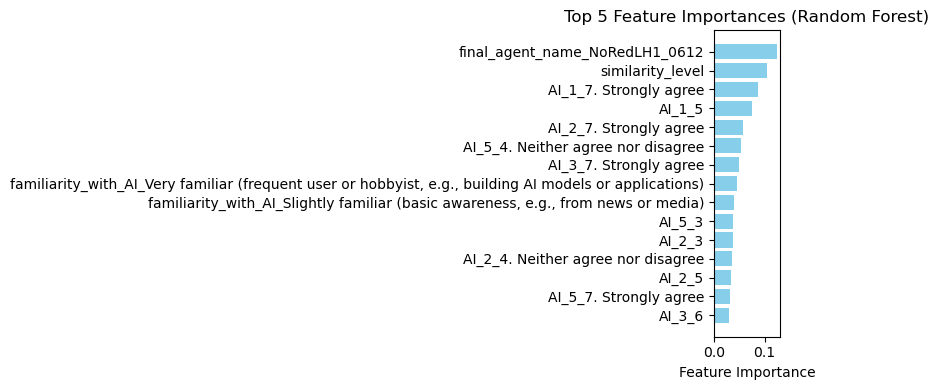

In [ ]:
import matplotlib.pyplot as plt

# Use feat_imp_df from cell 95 (Random Forest feature importances)
top5 = feat_imp_df.head(15)

plt.figure(figsize=(8, 4))
plt.barh(top5['feature'], top5['importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top 5 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

### Predict users Choices

In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'similarity_level', 'Trust_the_agent',
       'feedback_score', 'prev_agent', 'update_agent', 'prev_agent_mean_score',
       'update_agent_mean_score', 'prev_agent_last_score',
       'update_agent_last_score', 'choice', 'good_choice', 'good_choice_last',
       'choice_time', 'examples_shown', 'board_index', 'improved_from_base',
       'improved_from_base_last', 'improved_from_prev_last',
       'improved_from_prev_mean', 'final_agent', 'final_agent_score'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare data for prediction
target = 'choice'
df = choice_results.copy()
ban_cols = [target, 'user_id', 'final_agent', 'final_agent_score', 'good_choice', 'good_choice_last', 'choice']
X_col = df.columns.difference(ban_cols)
X = df.loc[:, X_col]
y = df[target]

# Drop rows with missing target
X = X.dropna()
y = y.loc[X.index]

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.375
              precision    recall  f1-score   support

         0.0       0.33      0.25      0.29         4
         1.0       0.40      0.50      0.44         4

    accuracy                           0.38         8
   macro avg       0.37      0.38      0.37         8
weighted avg       0.37      0.38      0.37         8

Random Forest Accuracy: 0.625
              precision    recall  f1-score   support

         0.0       0.60      0.75      0.67         4
         1.0       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



In [ ]:
y_test.value_counts()

choice
0.0    4
1.0    4
Name: count, dtype: int64

In [ ]:
import pandas as pd


# Get feature names and coefficients from the trained LogisticRegression model
feature_names = X_encoded.columns
feature_importances = lr.coef_[0]

# Create a DataFrame for feature importances
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by absolute importance
feat_imp_df = feat_imp_df.reindex(feat_imp_df['importance'].abs().sort_values(ascending=False).index)

print(list(feat_imp_df['feature']))
print(list(feat_imp_df['importance']))

['update_agent_mean_score', 'prev_agent_NoRedLH1_0612', 'improved_from_base_last', 'prev_agent_OnlyBlueLH_0706', 'prev_agent_mean_score', 'update_agent_OnlyBlueLH_0706', 'improved_from_prev_mean', 'examples_shown', 'prev_agent_last_score', 'improved_from_base', 'update_agent_AllColorsLL1_0526', 'prev_agent_OnlyGreenLL_0429', 'similarity_level', 'board_index', 'update_agent_NoRedLH1_0612', 'prev_agent_OnlyBlueLL_0625', 'update_agent_OnlyBlueLL_0625', 'prev_agent_AllColorsLL1_0526', 'improved_from_prev_last', 'update_agent_last_score', 'choice_time', 'episode', 'feedback_score', 'Trust_the_agent', 'update_agent_OnlyGreenLL_0429']
[0.9125759126086818, -0.868806456701969, -0.8368517503224584, 0.47160914285853534, 0.4481903612789236, -0.43490951887616686, 0.42424303413037484, -0.42070575768088386, -0.3400590440301653, 0.24925262776047247, -0.24739804871646695, -0.24476494025258436, 0.22781875323709433, -0.21311309359216854, 0.18846446906553663, 0.17588405189687184, 0.17530016012499433, -0.1